In [333]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from scipy.stats import ttest_ind,zscore

import warnings
warnings.filterwarnings("ignore")

In [334]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'blackrock.csv', 'Blackrock_Risk_Analysis.ipynb', 'monthly_credit_vs_debit.png']


In [335]:
df = pd.read_csv("blackrock.csv")

In [336]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,47387.11457,2980.571037,0.780701,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,55806.54015,27996.690070,0.299268,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,51080.47837,81482.156180,0.388445,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,70472.70472,39598.371940,0.561809,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,29830.48767,111731.993700,0.655635,391,20


In [337]:
df.shape

(800, 15)

In [338]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [340]:
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,100.697500,54501.866711,72947.111696,0.466517,580.015000,125.245000
std,58.592319,29676.379125,34206.072059,0.233783,154.075237,67.295139
min,1.000000,-27916.911650,-35891.001750,-0.290309,306.000000,6.000000
25%,50.750000,34600.682150,51133.057895,0.312410,451.750000,68.000000
50%,98.500000,55524.078060,73006.751950,0.459326,575.000000,127.000000
75%,154.000000,73485.547887,94553.225110,0.630247,712.250000,183.250000
max,199.000000,165004.536900,171767.657800,1.200214,849.000000,239.000000


In [341]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [342]:
df.duplicated().sum()

0

In [343]:
df["TransactionDate"].dtype

dtype('O')

In [344]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [345]:
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month_name()
df["Month_Number"] = df["TransactionDate"].dt.month

In [346]:
df[["AccountType", "TransactionType", "Region", "CreditRating"]].dtypes

AccountType        object
TransactionType    object
Region             object
CreditRating        int64
dtype: object

In [347]:
df["AccountType"] = df["AccountType"].astype(str).str.title().str.strip()

df["TransactionType"] = df["TransactionType"].astype(str).str.title().str.strip()

df["Region"] = df["Region"].astype(str).str.title().str.strip()

df["CreditRating"] = df["CreditRating"].astype(str).str.upper().str.strip()

In [348]:
df[["AccountType", "TransactionType", "Region", "CreditRating"]].head()

,AccountType,TransactionType,Region,CreditRating
0,Credit,Withdrawal,West,784
1,Current,Payment,South,336
2,Current,Withdrawal,North,712
3,Loan,Deposit,Central,414
4,Loan,Deposit,East,391


In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    object        
 14  TenureMont

In [350]:
df.dtypes

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                 object
TenureMonths                  int64
Year                          int32
Month                        object
Month_Number                  int32
dtype: object

In [351]:
df["TransactionType"].value_counts()

TransactionType
Withdrawal    214
Transfer      208
Payment       196
Deposit       182
Name: count, dtype: int64

In [352]:
df["TransactionCategory"] = df["TransactionType"].map({
    "Deposit": "Credit",
    "Withdrawal": "Debit",
    "Payment": "Debit",
    "Transfer": "Transfer"
})

In [353]:
df[["TransactionType", "TransactionCategory"]].drop_duplicates()

,TransactionType,TransactionCategory
0,Withdrawal,Debit
1,Payment,Debit
3,Deposit,Credit
6,Transfer,Transfer


In [354]:
df["TransactionCategory"].value_counts()

TransactionCategory
Debit       410
Transfer    208
Credit      182
Name: count, dtype: int64

In [355]:
df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M")

## TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS

In [356]:
monthly_summary = df.groupby(
    ["TransactionMonth", "TransactionCategory"]
)["TransactionAmount"].sum().reset_index()

monthly_summary

,TransactionMonth,TransactionCategory,TransactionAmount
0,2023-01,Credit,4.532878e+05
1,2023-01,Debit,1.329907e+06
2,2023-01,Transfer,4.489836e+05
3,2023-02,Credit,5.565913e+05
4,2023-02,Debit,1.674318e+06
5,2023-02,Transfer,9.357860e+05
6,2023-03,Credit,4.055112e+05
7,2023-03,Debit,1.397223e+06
8,2023-03,Transfer,5.164688e+05
9,2023-04,Credit,3.289578e+05


In [357]:
monthly_pivot = monthly_summary.pivot_table(
    index="TransactionMonth",
    columns="TransactionCategory",
    values="TransactionAmount",
    aggfunc="sum",
    fill_value=0
).reset_index()

monthly_pivot

TransactionCategory,TransactionMonth,Credit,Debit,Transfer
0,2023-01,4.532878e+05,1.329907e+06,4.489836e+05
1,2023-02,5.565913e+05,1.674318e+06,9.357860e+05
2,2023-03,4.055112e+05,1.397223e+06,5.164688e+05
3,2023-04,3.289578e+05,1.273478e+06,4.971673e+05
4,2023-05,9.335588e+05,1.320213e+06,1.021446e+06
5,2023-06,6.760825e+05,5.318630e+05,4.576015e+05
6,2023-07,4.865498e+05,1.047057e+06,3.758407e+05
7,2023-08,8.198514e+04,1.511240e+06,4.224687e+05
8,2023-09,7.491474e+05,1.565614e+06,6.301562e+05
9,2023-10,1.322052e+06,1.973337e+06,8.729308e+05


In [358]:
monthly_pivot["Net_Transaction"] = (
    monthly_pivot["Credit"] -
    monthly_pivot["Debit"]
)

In [359]:
monthly_pivot

TransactionCategory,TransactionMonth,Credit,Debit,Transfer,Net_Transaction
0,2023-01,4.532878e+05,1.329907e+06,4.489836e+05,-8.766195e+05
1,2023-02,5.565913e+05,1.674318e+06,9.357860e+05,-1.117726e+06
2,2023-03,4.055112e+05,1.397223e+06,5.164688e+05,-9.917113e+05
3,2023-04,3.289578e+05,1.273478e+06,4.971673e+05,-9.445206e+05
4,2023-05,9.335588e+05,1.320213e+06,1.021446e+06,-3.866543e+05
5,2023-06,6.760825e+05,5.318630e+05,4.576015e+05,1.442195e+05
6,2023-07,4.865498e+05,1.047057e+06,3.758407e+05,-5.605071e+05
7,2023-08,8.198514e+04,1.511240e+06,4.224687e+05,-1.429255e+06
8,2023-09,7.491474e+05,1.565614e+06,6.301562e+05,-8.164665e+05
9,2023-10,1.322052e+06,1.973337e+06,8.729308e+05,-6.512850e+05


In [360]:
df["TransactionCategory"] = df["TransactionType"].map({
    "Deposit": "Credit",
    "Withdrawal": "Debit",
    "Payment": "Debit",
    "Transfer": "Transfer"
})

In [361]:
df[["TransactionType", "TransactionCategory"]].drop_duplicates()

,TransactionType,TransactionCategory
0,Withdrawal,Debit
1,Payment,Debit
3,Deposit,Credit
6,Transfer,Transfer


In [362]:
monthly_summary = df.groupby(
    ["TransactionMonth", "TransactionCategory"]
)["TransactionAmount"].sum().reset_index()

monthly_summary

,TransactionMonth,TransactionCategory,TransactionAmount
0,2023-01,Credit,4.532878e+05
1,2023-01,Debit,1.329907e+06
2,2023-01,Transfer,4.489836e+05
3,2023-02,Credit,5.565913e+05
4,2023-02,Debit,1.674318e+06
5,2023-02,Transfer,9.357860e+05
6,2023-03,Credit,4.055112e+05
7,2023-03,Debit,1.397223e+06
8,2023-03,Transfer,5.164688e+05
9,2023-04,Credit,3.289578e+05


In [363]:
monthly_pivot = monthly_summary.pivot_table(
    index="TransactionMonth",
    columns="TransactionCategory",
    values="TransactionAmount",
    aggfunc="sum",
    fill_value=0
).reset_index()

monthly_pivot

TransactionCategory,TransactionMonth,Credit,Debit,Transfer
0,2023-01,4.532878e+05,1.329907e+06,4.489836e+05
1,2023-02,5.565913e+05,1.674318e+06,9.357860e+05
2,2023-03,4.055112e+05,1.397223e+06,5.164688e+05
3,2023-04,3.289578e+05,1.273478e+06,4.971673e+05
4,2023-05,9.335588e+05,1.320213e+06,1.021446e+06
5,2023-06,6.760825e+05,5.318630e+05,4.576015e+05
6,2023-07,4.865498e+05,1.047057e+06,3.758407e+05
7,2023-08,8.198514e+04,1.511240e+06,4.224687e+05
8,2023-09,7.491474e+05,1.565614e+06,6.301562e+05
9,2023-10,1.322052e+06,1.973337e+06,8.729308e+05


In [364]:
monthly_pivot["Net_Transaction"] = (
    monthly_pivot["Credit"] -
    monthly_pivot["Debit"]
)

monthly_pivot

TransactionCategory,TransactionMonth,Credit,Debit,Transfer,Net_Transaction
0,2023-01,4.532878e+05,1.329907e+06,4.489836e+05,-8.766195e+05
1,2023-02,5.565913e+05,1.674318e+06,9.357860e+05,-1.117726e+06
2,2023-03,4.055112e+05,1.397223e+06,5.164688e+05,-9.917113e+05
3,2023-04,3.289578e+05,1.273478e+06,4.971673e+05,-9.445206e+05
4,2023-05,9.335588e+05,1.320213e+06,1.021446e+06,-3.866543e+05
5,2023-06,6.760825e+05,5.318630e+05,4.576015e+05,1.442195e+05
6,2023-07,4.865498e+05,1.047057e+06,3.758407e+05,-5.605071e+05
7,2023-08,8.198514e+04,1.511240e+06,4.224687e+05,-1.429255e+06
8,2023-09,7.491474e+05,1.565614e+06,6.301562e+05,-8.164665e+05
9,2023-10,1.322052e+06,1.973337e+06,8.729308e+05,-6.512850e+05


In [365]:
df[["TransactionType", "TransactionCategory"]].drop_duplicates()

,TransactionType,TransactionCategory
0,Withdrawal,Debit
1,Payment,Debit
3,Deposit,Credit
6,Transfer,Transfer


In [366]:
df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M")

In [367]:
monthly_summary = df.groupby(
    ["TransactionMonth", "TransactionCategory"]
)["TransactionAmount"].sum().reset_index()

In [368]:
monthly_summary

,TransactionMonth,TransactionCategory,TransactionAmount
0,2023-01,Credit,4.532878e+05
1,2023-01,Debit,1.329907e+06
2,2023-01,Transfer,4.489836e+05
3,2023-02,Credit,5.565913e+05
4,2023-02,Debit,1.674318e+06
5,2023-02,Transfer,9.357860e+05
6,2023-03,Credit,4.055112e+05
7,2023-03,Debit,1.397223e+06
8,2023-03,Transfer,5.164688e+05
9,2023-04,Credit,3.289578e+05


In [369]:
monthly_pivot = monthly_summary.pivot_table(
    index="TransactionMonth",
    columns="TransactionCategory",
    values="TransactionAmount",
    aggfunc="sum",
    fill_value=0
).reset_index()

In [370]:
monthly_pivot

TransactionCategory,TransactionMonth,Credit,Debit,Transfer
0,2023-01,4.532878e+05,1.329907e+06,4.489836e+05
1,2023-02,5.565913e+05,1.674318e+06,9.357860e+05
2,2023-03,4.055112e+05,1.397223e+06,5.164688e+05
3,2023-04,3.289578e+05,1.273478e+06,4.971673e+05
4,2023-05,9.335588e+05,1.320213e+06,1.021446e+06
5,2023-06,6.760825e+05,5.318630e+05,4.576015e+05
6,2023-07,4.865498e+05,1.047057e+06,3.758407e+05
7,2023-08,8.198514e+04,1.511240e+06,4.224687e+05
8,2023-09,7.491474e+05,1.565614e+06,6.301562e+05
9,2023-10,1.322052e+06,1.973337e+06,8.729308e+05


In [371]:
monthly_pivot["Net_Transaction"] = (
    monthly_pivot["Credit"] - monthly_pivot["Debit"]
)

In [372]:
monthly_pivot

TransactionCategory,TransactionMonth,Credit,Debit,Transfer,Net_Transaction
0,2023-01,4.532878e+05,1.329907e+06,4.489836e+05,-8.766195e+05
1,2023-02,5.565913e+05,1.674318e+06,9.357860e+05,-1.117726e+06
2,2023-03,4.055112e+05,1.397223e+06,5.164688e+05,-9.917113e+05
3,2023-04,3.289578e+05,1.273478e+06,4.971673e+05,-9.445206e+05
4,2023-05,9.335588e+05,1.320213e+06,1.021446e+06,-3.866543e+05
5,2023-06,6.760825e+05,5.318630e+05,4.576015e+05,1.442195e+05
6,2023-07,4.865498e+05,1.047057e+06,3.758407e+05,-5.605071e+05
7,2023-08,8.198514e+04,1.511240e+06,4.224687e+05,-1.429255e+06
8,2023-09,7.491474e+05,1.565614e+06,6.301562e+05,-8.164665e+05
9,2023-10,1.322052e+06,1.973337e+06,8.729308e+05,-6.512850e+05


In [373]:
monthly_pivot.style.format({
    "Credit": "{:,.0f}",
    "Debit": "{:,.0f}",
    "Transfer": "{:,.0f}",
    "Net_Transaction": "{:,.0f}"
})

TransactionCategory,TransactionMonth,Credit,Debit,Transfer,Net_Transaction
0,2023-01,"453,288","1,329,907","448,984","-876,619"
1,2023-02,"556,591","1,674,318","935,786","-1,117,726"
2,2023-03,"405,511","1,397,223","516,469","-991,711"
3,2023-04,"328,958","1,273,478","497,167","-944,521"
4,2023-05,"933,559","1,320,213","1,021,446","-386,654"
5,2023-06,"676,082","531,863","457,601","144,219"
6,2023-07,"486,550","1,047,057","375,841","-560,507"
7,2023-08,"81,985","1,511,240","422,469","-1,429,255"
8,2023-09,"749,147","1,565,614","630,156","-816,467"
9,2023-10,"1,322,052","1,973,337","872,931","-651,285"


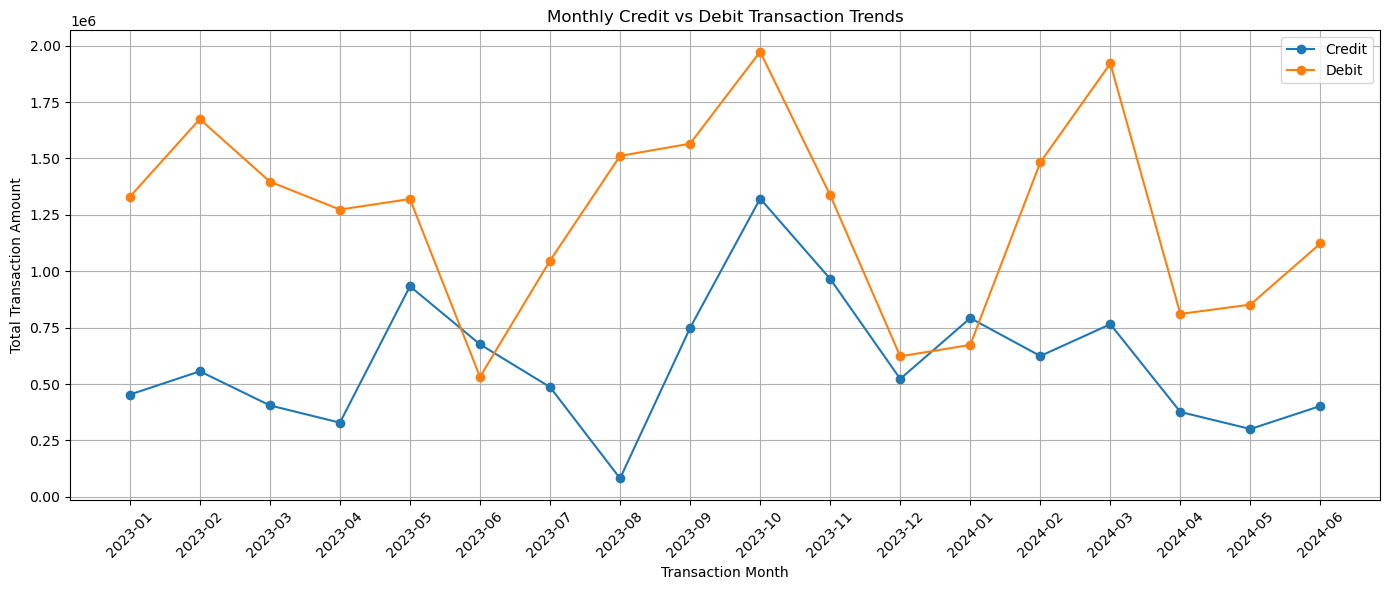

In [374]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_pivot["TransactionMonth"].astype(str),
    monthly_pivot["Credit"],
    marker="o",
    label="Credit"
)

plt.plot(
    monthly_pivot["TransactionMonth"].astype(str),
    monthly_pivot["Debit"],
    marker="o",
    label="Debit"
)

plt.title("Monthly Credit vs Debit Transaction Trends")
plt.xlabel("Transaction Month")
plt.ylabel("Total Transaction Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

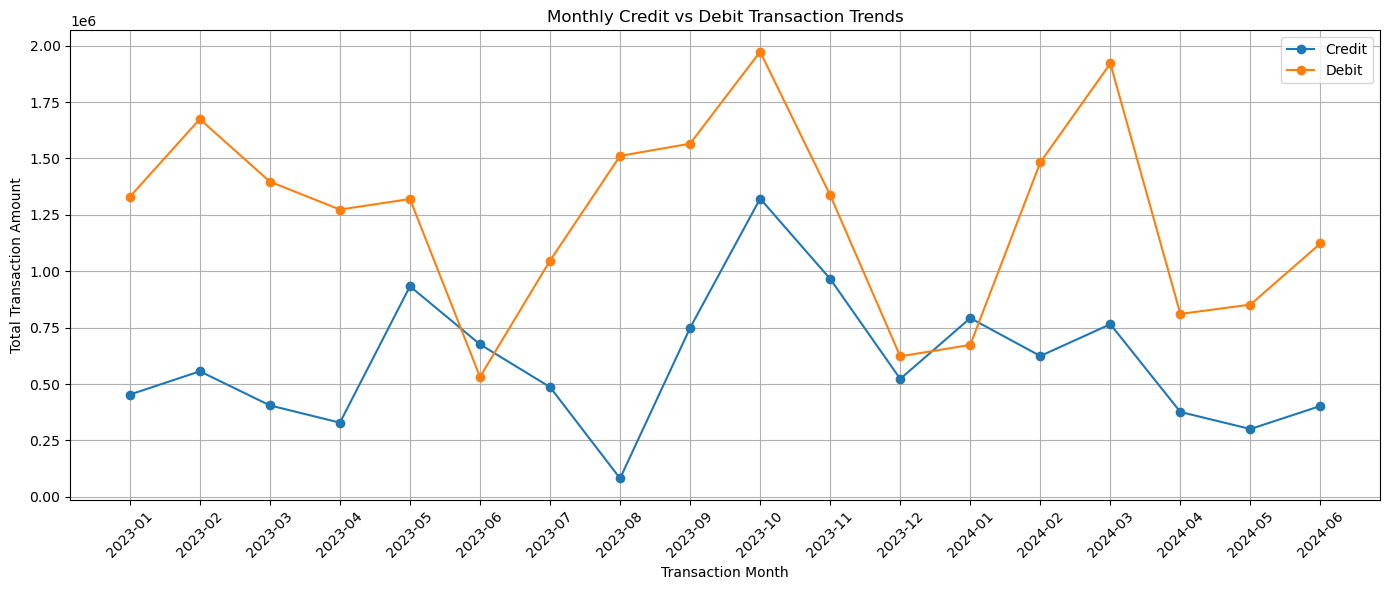

In [375]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_pivot["TransactionMonth"].astype(str),
    monthly_pivot["Credit"],
    marker="o",
    label="Credit"
)

plt.plot(
    monthly_pivot["TransactionMonth"].astype(str),
    monthly_pivot["Debit"],
    marker="o",
    label="Debit"
)

plt.title("Monthly Credit vs Debit Transaction Trends")
plt.xlabel("Transaction Month")
plt.ylabel("Total Transaction Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "monthly_credit_vs_debit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insights – Credit vs Debit Trend

- The trend shows that debit transaction values were generally higher than credit transaction values throughout the analysis period.
- Debit activity peaked in October 2023 at approximately 1.97 million, while credit activity also reached its highest level in October 2023 at approximately 1.32 million.
- Credit activity was particularly low in August 2023 at approximately 0.08 million, while debit activity remained high at approximately 1.51 million. This resulted in the most negative monthly net transaction value.
- The gap between credit and debit activity narrowed significantly in June 2023 and January 2024, when credit transactions exceeded debit transactions.
- The overall trend suggests that outgoing financial activity was generally stronger than incoming deposit activity, highlighting the importance of analyzing customer balances and risk indicators alongside transaction patterns.

# Task 2 – Part 2: Yearly Transaction Summary

In [376]:
yearly_summary = df.groupby(
    ["Year", "TransactionCategory"]
)["TransactionAmount"].sum().reset_index()

yearly_summary

,Year,TransactionCategory,TransactionAmount
0,2023,Credit,7.482764e+06
1,2023,Debit,1.558457e+07
2,2023,Transfer,7.407147e+06
3,2024,Credit,3.262322e+06
4,2024,Debit,6.863625e+06
5,2024,Transfer,3.001066e+06


In [377]:
yearly_pivot = yearly_summary.pivot_table(
    index="Year",
    columns="TransactionCategory",
    values="TransactionAmount",
    aggfunc="sum",
    fill_value=0
).reset_index()

yearly_pivot

TransactionCategory,Year,Credit,Debit,Transfer
0,2023,7.482764e+06,1.558457e+07,7.407147e+06
1,2024,3.262322e+06,6.863625e+06,3.001066e+06


In [378]:
yearly_pivot["Net_Transaction"] = (
    yearly_pivot["Credit"] -
    yearly_pivot["Debit"]
)

In [379]:
yearly_pivot

TransactionCategory,Year,Credit,Debit,Transfer,Net_Transaction
0,2023,7.482764e+06,1.558457e+07,7.407147e+06,-8.101805e+06
1,2024,3.262322e+06,6.863625e+06,3.001066e+06,-3.601303e+06


In [380]:
yearly_pivot.style.format({
    "Credit": "{:,.2f}",
    "Debit": "{:,.2f}",
    "Transfer": "{:,.2f}",
    "Net_Transaction": "{:,.2f}"
})

TransactionCategory,Year,Credit,Debit,Transfer,Net_Transaction
0,2023,"7,482,763.78","15,584,568.92","7,407,146.76","-8,101,805.14"
1,2024,"3,262,322.11","6,863,625.42","3,001,066.37","-3,601,303.31"


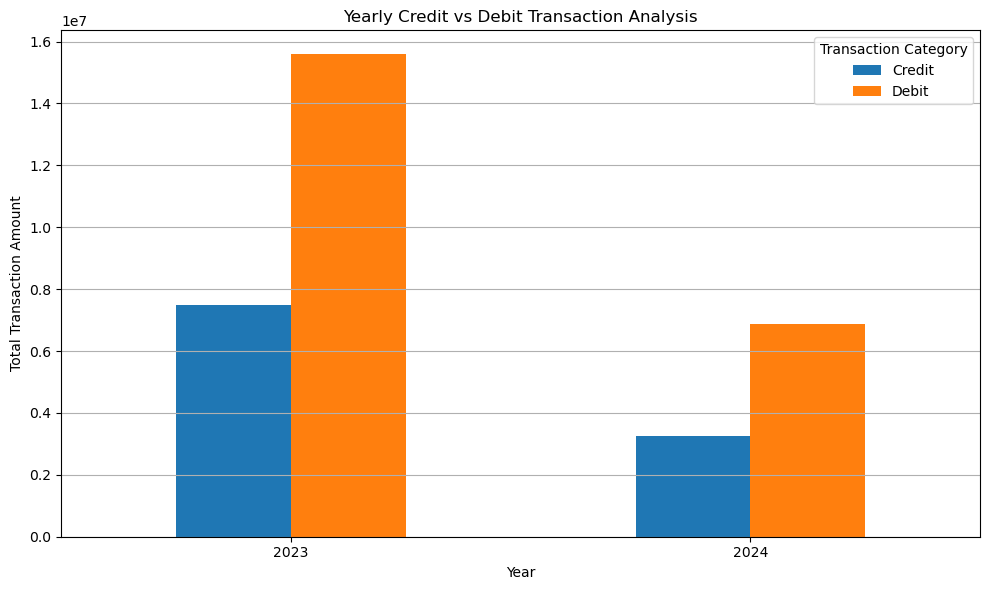

In [381]:
yearly_chart = yearly_pivot.set_index("Year")[["Credit", "Debit"]]

yearly_chart.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Yearly Credit vs Debit Transaction Analysis")
plt.xlabel("Year")
plt.ylabel("Total Transaction Amount")
plt.xticks(rotation=0)
plt.legend(title="Transaction Category")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

# The dataset contains 12 months of transaction data for 2023 but only 6 months for 2024. Therefore, yearly totals for 2023 and 2024 should not be directly compared without considering the difference in observation periods.

## Key Insights – Yearly Transaction Analysis

- In 2023, total credit transactions were approximately 7.48 million, while total debit transactions were approximately 15.58 million, resulting in a negative net transaction volume of approximately -8.10 million.
- In 2024, the dataset recorded approximately 3.26 million in credit transactions and 6.86 million in debit transactions, resulting in a negative net transaction volume of approximately -3.60 million.
- Debit transaction volume was substantially higher than credit transaction volume in both years, indicating that outgoing transaction activity exceeded incoming deposit activity.
- Transfer activity was significant in both periods, with approximately 7.41 million recorded in 2023 and 3.00 million in the available 2024 data.
- Both years recorded negative net transaction volumes, suggesting that debit activity generally exceeded credit inflows throughout the analysis period.
- The 2024 values should not be directly compared with 2023 totals because the dataset contains 12 months of data for 2023 but only 6 months of data for 2024.
- The results indicate a consistent pattern of higher debit activity relative to credit activity, which should be further investigated alongside account balances, risk scores, and customer activity levels.

In [382]:
yearly_pivot

TransactionCategory,Year,Credit,Debit,Transfer,Net_Transaction
0,2023,7.482764e+06,1.558457e+07,7.407147e+06,-8.101805e+06
1,2024,3.262322e+06,6.863625e+06,3.001066e+06,-3.601303e+06


In [383]:
yearly_pivot.style.format({
    "Credit": "{:,.0f}",
    "Debit": "{:,.0f}",
    "Transfer": "{:,.0f}",
    "Net_Transaction": "{:,.0f}"
})

TransactionCategory,Year,Credit,Debit,Transfer,Net_Transaction
0,2023,"7,482,764","15,584,569","7,407,147","-8,101,805"
1,2024,"3,262,322","6,863,625","3,001,066","-3,601,303"


In [384]:
monthly_yearly_avg = df.groupby(
    ["Year", "TransactionCategory"]
)["TransactionAmount"].sum().reset_index()

monthly_yearly_avg

,Year,TransactionCategory,TransactionAmount
0,2023,Credit,7.482764e+06
1,2023,Debit,1.558457e+07
2,2023,Transfer,7.407147e+06
3,2024,Credit,3.262322e+06
4,2024,Debit,6.863625e+06
5,2024,Transfer,3.001066e+06


In [385]:
monthly_avg = monthly_pivot.copy()

monthly_avg["Year"] = monthly_avg["TransactionMonth"].dt.year

monthly_avg = monthly_avg.groupby("Year")[
    ["Credit", "Debit", "Transfer"]
].mean().reset_index()

monthly_avg["Net_Transaction"] = (
    monthly_avg["Credit"] - monthly_avg["Debit"]
)

monthly_avg

TransactionCategory,Year,Credit,Debit,Transfer,Net_Transaction
0,2023,623563.648657,1.298714e+06,617262.230089,-675150.428425
1,2024,543720.351983,1.143938e+06,500177.727755,-600217.218113


# Task 2 – Part 3: Account Performance Analysis

In [386]:
credit_by_account = df[
    df["TransactionCategory"] == "Credit"
].groupby("AccountID")["TransactionAmount"].sum()

credit_by_account

AccountID
ACC10117     56402.839110
ACC10996     60870.237210
ACC11188    138883.978382
ACC11285     71079.928350
ACC12182    130450.262350
                ...      
ACC94203     58097.656420
ACC94907     40232.329050
ACC96277    154092.773210
ACC97225     74213.775400
ACC99117     92159.600750
Name: TransactionAmount, Length: 117, dtype: float64

In [387]:
debit_by_account = df[
    df["TransactionCategory"] == "Debit"
].groupby("AccountID")["TransactionAmount"].sum()

debit_by_account

AccountID
ACC10117    107654.532150
ACC10996    297946.784800
ACC11062     96820.851390
ACC11188    145348.385422
ACC11285    168577.238237
                ...      
ACC96868     88102.303870
ACC97225     31988.720930
ACC97411    365710.863533
ACC99409     72998.159970
ACC99549    121474.083870
Name: TransactionAmount, Length: 171, dtype: float64

In [388]:
account_performance = pd.DataFrame({
    "Total_Credit": credit_by_account,
    "Total_Debit": debit_by_account
}).fillna(0)

account_performance

,Total_Credit,Total_Debit
AccountID,,
ACC10117,56402.839110,107654.532150
ACC10996,60870.237210,297946.784800
ACC11062,0.000000,96820.851390
ACC11188,138883.978382,145348.385422
ACC11285,71079.928350,168577.238237
...,...,...
ACC97225,74213.775400,31988.720930
ACC97411,0.000000,365710.863533
ACC99117,92159.600750,0.000000


In [389]:
account_performance["Net_Inflow"] = (
    account_performance["Total_Credit"] -
    account_performance["Total_Debit"]
)

account_performance

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC10117,56402.839110,107654.532150,-51251.693040
ACC10996,60870.237210,297946.784800,-237076.547590
ACC11062,0.000000,96820.851390,-96820.851390
ACC11188,138883.978382,145348.385422,-6464.407040
ACC11285,71079.928350,168577.238237,-97497.309887
...,...,...,...
ACC97225,74213.775400,31988.720930,42225.054470
ACC97411,0.000000,365710.863533,-365710.863533
ACC99117,92159.600750,0.000000,92159.600750


In [390]:
top_accounts = account_performance.sort_values(
    "Net_Inflow",
    ascending=False
).head(10)

top_accounts

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC88286,284230.600790,0.00000,284230.600790
ACC21719,281795.517800,7066.33208,274729.185720
ACC51200,251699.760080,50230.02764,201469.732440
ACC28295,262087.212310,62636.51939,199450.692920
ACC88252,183519.248820,0.00000,183519.248820
ACC83269,180850.726890,0.00000,180850.726890
ACC88449,184286.917040,50072.93893,134213.978110
ACC32627,141764.346710,15770.63227,125993.714440
ACC31902,103237.587600,0.00000,103237.587600


In [391]:
top_accounts.style.format({
    "Total_Credit": "{:,.0f}",
    "Total_Debit": "{:,.0f}",
    "Net_Inflow": "{:,.0f}"
})

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC88286,"284,231",0,"284,231"
ACC21719,"281,796","7,066","274,729"
ACC51200,"251,700","50,230","201,470"
ACC28295,"262,087","62,637","199,451"
ACC88252,"183,519",0,"183,519"
ACC83269,"180,851",0,"180,851"
ACC88449,"184,287","50,073","134,214"
ACC32627,"141,764","15,771","125,994"
ACC31902,"103,238",0,"103,238"


In [392]:
bottom_accounts = account_performance.sort_values(
    "Net_Inflow",
    ascending=True
).head(10)

bottom_accounts

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC45101,35224.62786,430644.575690,-395419.947830
ACC35419,32955.23345,398856.436650,-365901.203200
ACC97411,0.00000,365710.863533,-365710.863533
ACC71938,0.00000,353666.209440,-353666.209440
ACC24070,0.00000,338136.693810,-338136.693810
ACC78581,0.00000,332353.939521,-332353.939521
ACC53466,62795.87281,377063.039840,-314267.167030
ACC11837,0.00000,280003.838417,-280003.838417
ACC81631,0.00000,272715.698320,-272715.698320


In [393]:
bottom_accounts.style.format({
    "Total_Credit": "{:,.0f}",
    "Total_Debit": "{:,.0f}",
    "Net_Inflow": "{:,.0f}"
})

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC45101,"35,225","430,645","-395,420"
ACC35419,"32,955","398,856","-365,901"
ACC97411,0,"365,711","-365,711"
ACC71938,0,"353,666","-353,666"
ACC24070,0,"338,137","-338,137"
ACC78581,0,"332,354","-332,354"
ACC53466,"62,796","377,063","-314,267"
ACC11837,0,"280,004","-280,004"
ACC81631,0,"272,716","-272,716"


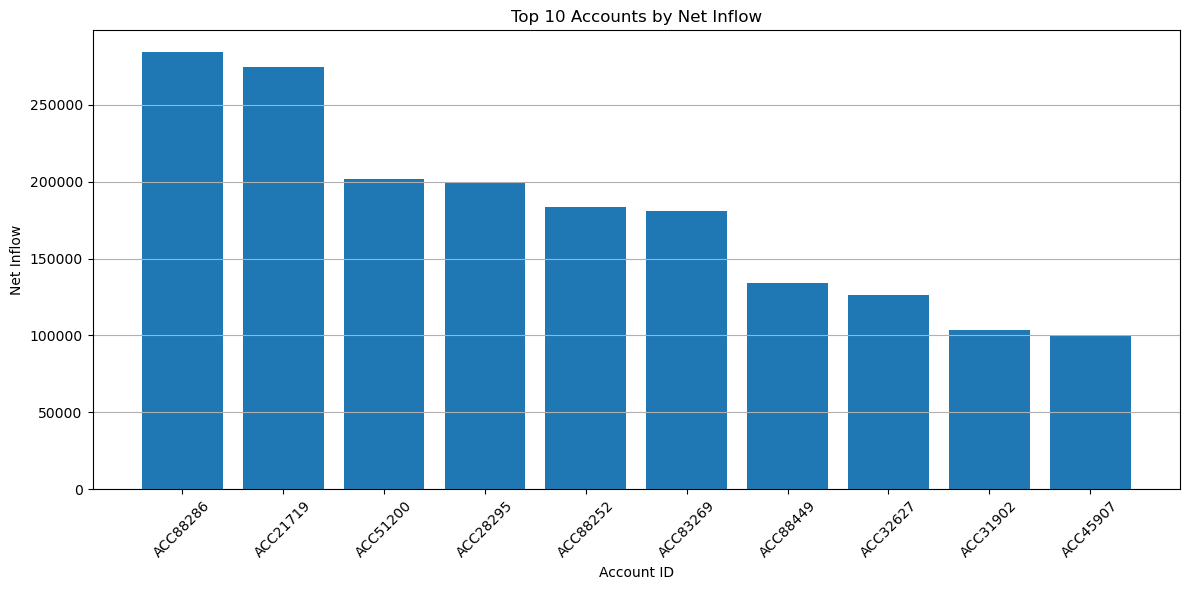

In [394]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_accounts.index.astype(str),
    top_accounts["Net_Inflow"]
)

plt.title("Top 10 Accounts by Net Inflow")
plt.xlabel("Account ID")
plt.ylabel("Net Inflow")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

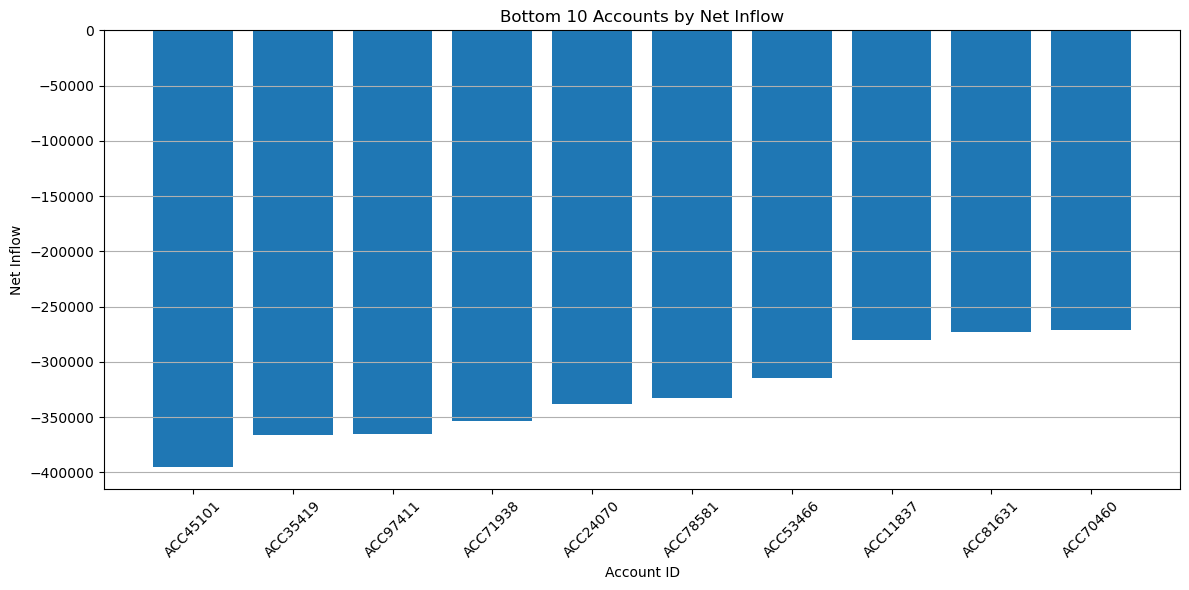

In [395]:
plt.figure(figsize=(12, 6))

plt.bar(
    bottom_accounts.index.astype(str),
    bottom_accounts["Net_Inflow"]
)

plt.title("Bottom 10 Accounts by Net Inflow")
plt.xlabel("Account ID")
plt.ylabel("Net Inflow")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [396]:
top_accounts

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC88286,284230.600790,0.00000,284230.600790
ACC21719,281795.517800,7066.33208,274729.185720
ACC51200,251699.760080,50230.02764,201469.732440
ACC28295,262087.212310,62636.51939,199450.692920
ACC88252,183519.248820,0.00000,183519.248820
ACC83269,180850.726890,0.00000,180850.726890
ACC88449,184286.917040,50072.93893,134213.978110
ACC32627,141764.346710,15770.63227,125993.714440
ACC31902,103237.587600,0.00000,103237.587600


In [397]:
bottom_accounts

,Total_Credit,Total_Debit,Net_Inflow
AccountID,,,
ACC45101,35224.62786,430644.575690,-395419.947830
ACC35419,32955.23345,398856.436650,-365901.203200
ACC97411,0.00000,365710.863533,-365710.863533
ACC71938,0.00000,353666.209440,-353666.209440
ACC24070,0.00000,338136.693810,-338136.693810
ACC78581,0.00000,332353.939521,-332353.939521
ACC53466,62795.87281,377063.039840,-314267.167030
ACC11837,0.00000,280003.838417,-280003.838417
ACC81631,0.00000,272715.698320,-272715.698320


## Key Insights – Top Performing Accounts by Net Inflow

- ACC88286 recorded the highest net inflow at approximately 284,231, making it the strongest account based on the selected net inflow measure.
- ACC21719 ranked second with a net inflow of approximately 274,729.
- Several top-performing accounts recorded no debit transactions during the observed period, including ACC88286, ACC88252, ACC83269, ACC31902, and ACC45907.
- ACC51200 and ACC28295 had comparatively higher debit activity but still maintained strong positive net inflows.
- Overall, the top-performing accounts were characterized by credit inflows that substantially exceeded debit outflows.
- These accounts may represent customers with strong deposit activity or accounts primarily used for receiving funds.
- Further analysis of account type, average balance, transaction frequency, and risk score is required to understand the underlying customer behavior and determine whether these high net inflows represent healthy financial activity or unusual transaction patterns.

## Key Insights – Bottom Performing Accounts by Net Inflow

- ACC45101 recorded the lowest net inflow at approximately -395,420, with debit transactions of approximately 430,645 compared with credit transactions of approximately 35,225.
- ACC35419 recorded the second-lowest net inflow at approximately -365,901, with debit activity substantially exceeding credit activity.
- Several bottom-performing accounts, including ACC97411, ACC71938, ACC24070, ACC78581, ACC11837, ACC81631, and ACC70460, recorded no credit transactions during the observed period while showing significant debit activity.
- The bottom-performing accounts are characterized by a strong imbalance between outgoing debit transactions and incoming credit transactions.
- Persistent negative net inflows may indicate potential liquidity pressure and should be investigated further using account balances, overdraft indicators, risk scores, and balance volatility.
- These accounts should not automatically be classified as high-risk based solely on net inflow. Additional risk indicators are required to confirm whether the observed transaction patterns represent genuine financial risk.

In [398]:
comparison_accounts = pd.concat([
    top_accounts.assign(Category="Top 10"),
    bottom_accounts.assign(Category="Bottom 10")
])

comparison_accounts

,Total_Credit,Total_Debit,Net_Inflow,Category
AccountID,,,,
ACC88286,284230.600790,0.000000,284230.600790,Top 10
ACC21719,281795.517800,7066.332080,274729.185720,Top 10
ACC51200,251699.760080,50230.027640,201469.732440,Top 10
ACC28295,262087.212310,62636.519390,199450.692920,Top 10
ACC88252,183519.248820,0.000000,183519.248820,Top 10
ACC83269,180850.726890,0.000000,180850.726890,Top 10
ACC88449,184286.917040,50072.938930,134213.978110,Top 10
ACC32627,141764.346710,15770.632270,125993.714440,Top 10
ACC31902,103237.587600,0.000000,103237.587600,Top 10


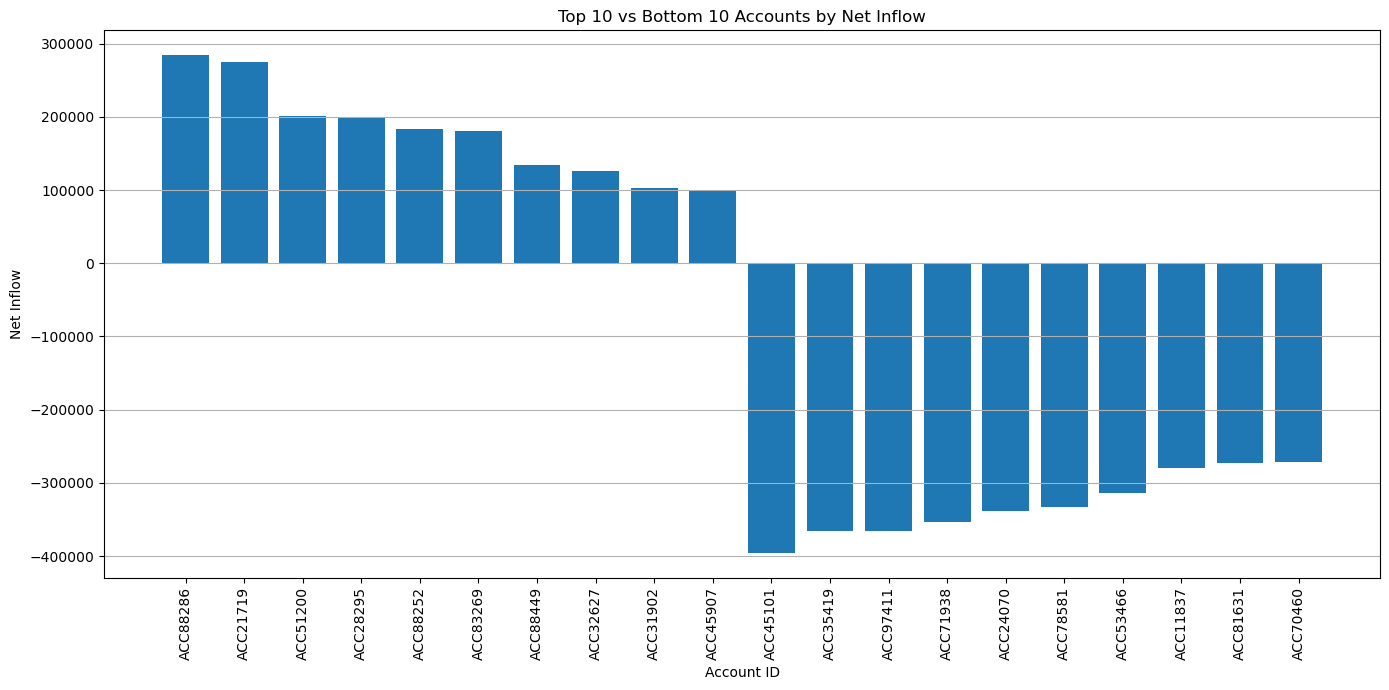

In [399]:
plt.figure(figsize=(14, 7))

plt.bar(
    comparison_accounts.index.astype(str),
    comparison_accounts["Net_Inflow"]
)

plt.title("Top 10 vs Bottom 10 Accounts by Net Inflow")
plt.xlabel("Account ID")
plt.ylabel("Net Inflow")

plt.xticks(rotation=90)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

# Task 2 – Part 4: Dormant / Inactive Account Detection.

In [400]:
df[["AccountID", "TransactionDate"]].head()

,AccountID,TransactionDate
0,ACC64393,2023-07-17
1,ACC66190,2023-01-13
2,ACC71426,2023-09-28
3,ACC49422,2023-02-05
4,ACC88252,2023-11-19


In [401]:
df["TransactionDate"].dtype

dtype('<M8[ns]')

In [402]:
df_sorted = df.sort_values(
    ["AccountID", "TransactionDate"]
).copy()

df_sorted.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month,Month_Number,TransactionCategory,TransactionMonth
549,171,CUST6735,ACC10117,Credit,Payment,Home Loan,Firm B,South,Manager 1,2023-09-13,56512.34987,115878.96740,0.736874,608,48,2023,September,9,Debit,2023-09
301,84,CUST9843,ACC10117,Loan,Withdrawal,Credit Card,Firm B,East,Manager 4,2023-09-28,12973.71185,90403.82826,0.578092,849,86,2023,September,9,Debit,2023-09
724,71,CUST9731,ACC10117,Current,Payment,Home Loan,Firm D,South,Manager 3,2023-12-09,38168.47043,64821.32547,0.611788,733,138,2023,December,12,Debit,2023-12
787,1,CUST6776,ACC10117,Current,Transfer,Personal Loan,Firm A,Central,Manager 3,2023-12-30,31566.83418,110014.01980,0.482986,485,219,2023,December,12,Transfer,2023-12
27,26,CUST4258,ACC10117,Loan,Transfer,Home Loan,Firm D,South,Manager 2,2024-01-12,51263.08136,71720.72400,0.375032,522,156,2024,January,1,Transfer,2024-01


In [403]:
df_sorted["PreviousTransactionDate"] = (
    df_sorted.groupby("AccountID")["TransactionDate"].shift(1)
)

In [404]:
df_sorted["Gap_Days"] = (
    df_sorted["TransactionDate"] -
    df_sorted["PreviousTransactionDate"]
).dt.days

In [405]:
df_sorted[
    [
        "AccountID",
        "TransactionDate",
        "PreviousTransactionDate",
        "Gap_Days"
    ]
].head(20)

,AccountID,TransactionDate,PreviousTransactionDate,Gap_Days
549,ACC10117,2023-09-13,NaT,NaN
301,ACC10117,2023-09-28,2023-09-13,15.0
724,ACC10117,2023-12-09,2023-09-28,72.0
787,ACC10117,2023-12-30,2023-12-09,21.0
27,ACC10117,2024-01-12,2023-12-30,13.0
547,ACC10117,2024-04-25,2024-01-12,104.0
69,ACC10996,2023-01-21,NaT,NaN
162,ACC10996,2023-02-05,2023-01-21,15.0
144,ACC10996,2023-06-19,2023-02-05,134.0
491,ACC10996,2023-10-06,2023-06-19,109.0


In [406]:
df_sorted["Inactive_Gap_Flag"] = (
    df_sorted["Gap_Days"] >= 60
)

df_sorted[
    [
        "AccountID",
        "TransactionDate",
        "PreviousTransactionDate",
        "Gap_Days",
        "Inactive_Gap_Flag"
    ]
].head(20)

,AccountID,TransactionDate,PreviousTransactionDate,Gap_Days,Inactive_Gap_Flag
549,ACC10117,2023-09-13,NaT,NaN,False
301,ACC10117,2023-09-28,2023-09-13,15.0,False
724,ACC10117,2023-12-09,2023-09-28,72.0,True
787,ACC10117,2023-12-30,2023-12-09,21.0,False
27,ACC10117,2024-01-12,2023-12-30,13.0,False
547,ACC10117,2024-04-25,2024-01-12,104.0,True
69,ACC10996,2023-01-21,NaT,NaN,False
162,ACC10996,2023-02-05,2023-01-21,15.0,False
144,ACC10996,2023-06-19,2023-02-05,134.0,True
491,ACC10996,2023-10-06,2023-06-19,109.0,True


In [407]:
inactive_gaps = df_sorted[
    df_sorted["Inactive_Gap_Flag"] == True
].copy()

inactive_gaps[
    [
        "AccountID",
        "PreviousTransactionDate",
        "TransactionDate",
        "Gap_Days"
    ]
]

,AccountID,PreviousTransactionDate,TransactionDate,Gap_Days
724,ACC10117,2023-09-28,2023-12-09,72.0
547,ACC10117,2024-01-12,2024-04-25,104.0
144,ACC10996,2023-02-05,2023-06-19,134.0
491,ACC10996,2023-06-19,2023-10-06,109.0
18,ACC11062,2023-02-14,2023-04-26,71.0
...,...,...,...,...
321,ACC97411,2023-03-26,2023-09-26,184.0
29,ACC97411,2023-10-31,2024-05-24,206.0
198,ACC99409,2023-08-18,2023-12-21,125.0
398,ACC99409,2023-12-21,2024-05-02,133.0


In [408]:
inactive_accounts = (
    inactive_gaps.groupby("AccountID")
    .agg(
        Max_Gap_Days=("Gap_Days", "max"),
        Number_of_Inactive_Gaps=("Gap_Days", "count")
    )
    .reset_index()
)

inactive_accounts.head(20)

,AccountID,Max_Gap_Days,Number_of_Inactive_Gaps
0,ACC10117,104.0,2
1,ACC10996,134.0,2
2,ACC11062,204.0,3
3,ACC11188,160.0,3
4,ACC11285,211.0,2
5,ACC11837,161.0,1
6,ACC12334,64.0,1
7,ACC13357,118.0,1
8,ACC15228,139.0,1
9,ACC15671,262.0,2


In [409]:
inactive_accounts["Account_Status"] = "Inactive/Dormant"

inactive_accounts.head(20)

,AccountID,Max_Gap_Days,Number_of_Inactive_Gaps,Account_Status
0,ACC10117,104.0,2,Inactive/Dormant
1,ACC10996,134.0,2,Inactive/Dormant
2,ACC11062,204.0,3,Inactive/Dormant
3,ACC11188,160.0,3,Inactive/Dormant
4,ACC11285,211.0,2,Inactive/Dormant
5,ACC11837,161.0,1,Inactive/Dormant
6,ACC12334,64.0,1,Inactive/Dormant
7,ACC13357,118.0,1,Inactive/Dormant
8,ACC15228,139.0,1,Inactive/Dormant
9,ACC15671,262.0,2,Inactive/Dormant


In [410]:
total_accounts = df["AccountID"].nunique()

inactive_account_count = inactive_accounts["AccountID"].nunique()

active_account_count = total_accounts - inactive_account_count

inactive_percentage = (
    inactive_account_count / total_accounts
) * 100

print("Total Accounts:", total_accounts)
print("Inactive/Dormant Accounts:", inactive_account_count)
print("Active Accounts:", active_account_count)
print("Inactive/Dormant Percentage:", round(inactive_percentage, 2), "%")

Total Accounts: 192
Inactive/Dormant Accounts: 172
Active Accounts: 20
Inactive/Dormant Percentage: 89.58 %


## Key Insights – Dormant / Inactive Account Analysis

- The analysis identified 192 unique accounts in the dataset.
- Out of these, 172 accounts (89.58%) were flagged as potentially inactive or dormant based on having a gap of 60 days or more between consecutive transactions.
- Only 20 accounts (10.42%) were classified as active under the selected transaction-gap criteria.
- The high proportion of potentially inactive accounts indicates that a large share of accounts had periods of limited transaction activity during the observation period.
- This pattern may indicate irregular customer engagement, seasonal account usage, or inactive accounts that are not frequently used for transactions.
- From a financial risk perspective, accounts with long periods of inactivity followed by sudden high-value transactions may require additional monitoring.
- The dormant/inactive flag is based only on transaction gaps and should not be considered a formal banking definition of a dormant account.
- Further investigation should combine inactivity patterns with transaction amounts, account balances, transaction frequency, and risk indicators to identify accounts that may require customer engagement or risk monitoring.

### Dormancy Criteria Used

For this analysis, an account was flagged as potentially inactive/dormant when the gap between two consecutive transactions was 60 days or more. The 60-day threshold was selected as an approximate representation of a two-month transaction gap, as required by the project guidelines. The first transaction of each account was excluded from gap analysis because there was no previous transaction available for comparison.

# TASK 3 – Customer Profile Building

## Task 3.1 – Activity Level Segmentation

In [411]:
account_activity = (
    df.groupby("AccountID")
    .size()
    .reset_index(name="Transaction_Frequency")
)

account_activity.head(10)

,AccountID,Transaction_Frequency
0,ACC10117,6
1,ACC10996,4
2,ACC11062,6
3,ACC11188,9
4,ACC11285,5
5,ACC11837,6
6,ACC12182,3
7,ACC12334,2
8,ACC13357,4
9,ACC15228,2


In [412]:
account_activity["Transaction_Frequency"].describe()

count    192.000000
mean       4.166667
std        2.021697
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       13.000000
Name: Transaction_Frequency, dtype: float64

In [413]:
def classify_activity(frequency):
    if frequency <= 3:
        return "Low"
    elif frequency <= 5:
        return "Medium"
    else:
        return "High"


account_activity["Activity_Level"] = (
    account_activity["Transaction_Frequency"]
    .apply(classify_activity)
)

account_activity.head(10)

,AccountID,Transaction_Frequency,Activity_Level
0,ACC10117,6,High
1,ACC10996,4,Medium
2,ACC11062,6,High
3,ACC11188,9,High
4,ACC11285,5,Medium
5,ACC11837,6,High
6,ACC12182,3,Low
7,ACC12334,2,Low
8,ACC13357,4,Medium
9,ACC15228,2,Low


In [414]:
activity_summary = (
    account_activity["Activity_Level"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
    .reset_index()
)

activity_summary.columns = [
    "Activity_Level",
    "Account_Count"
]

activity_summary

,Activity_Level,Account_Count
0,High,45
1,Medium,68
2,Low,79


In [415]:
activity_summary["Percentage"] = (
    activity_summary["Account_Count"] /
    activity_summary["Account_Count"].sum()
) * 100

activity_summary

,Activity_Level,Account_Count,Percentage
0,High,45,23.437500
1,Medium,68,35.416667
2,Low,79,41.145833


In [416]:
activity_summary.style.format({
    "Account_Count": "{:,.0f}",
    "Percentage": "{:.2f}%"
})

,Activity_Level,Account_Count,Percentage
0,High,45,23.44%
1,Medium,68,35.42%
2,Low,79,41.15%


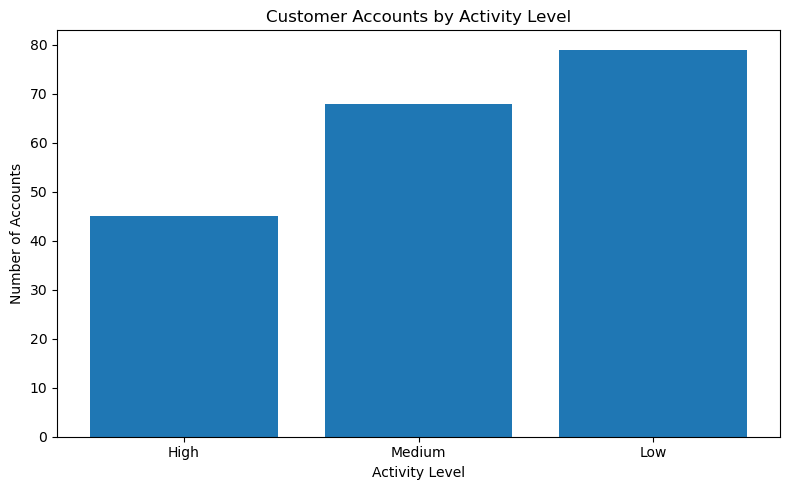

In [417]:
plt.figure(figsize=(8, 5))

plt.bar(
    activity_summary["Activity_Level"],
    activity_summary["Account_Count"]
)

plt.title("Customer Accounts by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Number of Accounts")

plt.tight_layout()
plt.show()

## Task 3.1 – Customer Activity Segmentation (Rubric-Based Analysis)

### Activity Segmentation Rubric

Accounts were segmented into Low, Medium, and High activity groups based on transaction frequency.

- **Low Activity:** 1–3 transactions per account
- **Medium Activity:** 4–5 transactions per account
- **High Activity:** 6 or more transactions per account

The thresholds were derived from the observed transaction-frequency distribution. The 25th percentile was 3 transactions, the median was 4 transactions, and the 75th percentile was 5 transactions. This data-driven approach was used to classify accounts according to their relative transaction activity.

### Key Insights

- Out of 192 accounts, 79 accounts (41.15%) were classified as Low Activity, making this the largest customer activity segment.
- 68 accounts (35.42%) were classified as Medium Activity, representing a substantial portion of the customer base.
- 45 accounts (23.44%) were classified as High Activity based on having six or more transactions.
- The majority of accounts (76.56%) fall into the Low or Medium activity categories, indicating that most accounts have relatively limited transaction frequency.
- The relatively smaller High Activity segment may represent customers who use their accounts more frequently for regular financial transactions.
- Low-activity accounts may benefit from targeted customer engagement strategies, while High Activity accounts should be monitored for transaction patterns and potential financial risk.

### Task 3.2 – Customer Segmentation by Average Balance and Transaction Volume

In [418]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'Month_Number',
       'TransactionCategory', 'TransactionMonth'],
      dtype='object')

In [419]:
customer_profile = (
    df.groupby("AccountID")
    .agg(
        Average_Balance=("AccountBalance", "mean"),
        Total_Transaction_Volume=("TransactionAmount", "sum"),
        Transaction_Frequency=("TransactionID", "count")
    )
    .reset_index()
)

customer_profile.head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency
0,ACC10117,81106.206188,246887.286800,6
1,ACC10996,101733.898198,358817.022010,4
2,ACC11062,57108.763888,328776.968270,6
3,ACC11188,80235.151167,386419.024114,9
4,ACC11285,71205.645238,284440.530857,5
5,ACC11837,69822.567937,280003.838417,6
6,ACC12182,103956.446880,180373.326160,3
7,ACC12334,71687.818925,38041.875690,2
8,ACC13357,82050.047215,233828.196970,4
9,ACC15228,130695.134600,97928.191220,2


In [420]:
customer_profile = customer_profile.merge(
    account_activity[["AccountID", "Activity_Level"]],
    on="AccountID",
    how="left"
)

customer_profile.head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level
0,ACC10117,81106.206188,246887.286800,6,High
1,ACC10996,101733.898198,358817.022010,4,Medium
2,ACC11062,57108.763888,328776.968270,6,High
3,ACC11188,80235.151167,386419.024114,9,High
4,ACC11285,71205.645238,284440.530857,5,Medium
5,ACC11837,69822.567937,280003.838417,6,High
6,ACC12182,103956.446880,180373.326160,3,Low
7,ACC12334,71687.818925,38041.875690,2,Low
8,ACC13357,82050.047215,233828.196970,4,Medium
9,ACC15228,130695.134600,97928.191220,2,Low


In [421]:
customer_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AccountID                 192 non-null    object 
 1   Average_Balance           192 non-null    float64
 2   Total_Transaction_Volume  192 non-null    float64
 3   Transaction_Frequency     192 non-null    int64  
 4   Activity_Level            192 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 7.6+ KB


In [422]:
customer_profile.describe()

,Average_Balance,Total_Transaction_Volume,Transaction_Frequency
count,192.000000,192.000000,192.000000
mean,74990.709390,227091.111297,4.166667
std,21351.526278,123839.160929,2.021697
min,23319.336055,10392.702450,1.000000
25%,63455.058162,137910.282023,3.000000
50%,72577.426682,207930.106625,4.000000
75%,85165.727267,295923.080535,5.000000
max,171767.657800,765315.963850,13.000000


In [423]:
customer_profile.head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level
0,ACC10117,81106.206188,246887.286800,6,High
1,ACC10996,101733.898198,358817.022010,4,Medium
2,ACC11062,57108.763888,328776.968270,6,High
3,ACC11188,80235.151167,386419.024114,9,High
4,ACC11285,71205.645238,284440.530857,5,Medium
5,ACC11837,69822.567937,280003.838417,6,High
6,ACC12182,103956.446880,180373.326160,3,Low
7,ACC12334,71687.818925,38041.875690,2,Low
8,ACC13357,82050.047215,233828.196970,4,Medium
9,ACC15228,130695.134600,97928.191220,2,Low


In [424]:
customer_profile[
    [
        "Average_Balance",
        "Total_Transaction_Volume"
    ]
].describe()

,Average_Balance,Total_Transaction_Volume
count,192.000000,192.000000
mean,74990.709390,227091.111297
std,21351.526278,123839.160929
min,23319.336055,10392.702450
25%,63455.058162,137910.282023
50%,72577.426682,207930.106625
75%,85165.727267,295923.080535
max,171767.657800,765315.963850


In [425]:
def classify_customer(row):
    if (
        row["Average_Balance"] >= 85165.727267
        and row["Total_Transaction_Volume"] >= 295923.080535
    ):
        return "High Balance - High Volume"
    
    elif (
        row["Average_Balance"] >= 85165.727267
        and row["Total_Transaction_Volume"] < 295923.080535
    ):
        return "High Balance - Low Volume"
    
    elif (
        row["Average_Balance"] < 85165.727267
        and row["Total_Transaction_Volume"] >= 295923.080535
    ):
        return "Low Balance - High Volume"
    
    else:
        return "Low Balance - Low Volume"


customer_profile["Financial_Segment"] = (
    customer_profile.apply(classify_customer, axis=1)
)

customer_profile.head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level,Financial_Segment
0,ACC10117,81106.206188,246887.286800,6,High,Low Balance - Low Volume
1,ACC10996,101733.898198,358817.022010,4,Medium,High Balance - High Volume
2,ACC11062,57108.763888,328776.968270,6,High,Low Balance - High Volume
3,ACC11188,80235.151167,386419.024114,9,High,Low Balance - High Volume
4,ACC11285,71205.645238,284440.530857,5,Medium,Low Balance - Low Volume
5,ACC11837,69822.567937,280003.838417,6,High,Low Balance - Low Volume
6,ACC12182,103956.446880,180373.326160,3,Low,High Balance - Low Volume
7,ACC12334,71687.818925,38041.875690,2,Low,Low Balance - Low Volume
8,ACC13357,82050.047215,233828.196970,4,Medium,Low Balance - Low Volume
9,ACC15228,130695.134600,97928.191220,2,Low,High Balance - Low Volume


In [426]:
financial_segment_summary = (
    customer_profile["Financial_Segment"]
    .value_counts()
    .reset_index()
)

financial_segment_summary.columns = [
    "Financial_Segment",
    "Account_Count"
]

financial_segment_summary["Percentage"] = (
    financial_segment_summary["Account_Count"]
    / financial_segment_summary["Account_Count"].sum()
) * 100

financial_segment_summary

,Financial_Segment,Account_Count,Percentage
0,Low Balance - Low Volume,105,54.6875
1,Low Balance - High Volume,39,20.3125
2,High Balance - Low Volume,39,20.3125
3,High Balance - High Volume,9,4.6875


In [427]:
financial_segment_summary.style.format({
    "Account_Count": "{:,.0f}",
    "Percentage": "{:.2f}%"
})

,Financial_Segment,Account_Count,Percentage
0,Low Balance - Low Volume,105,54.69%
1,Low Balance - High Volume,39,20.31%
2,High Balance - Low Volume,39,20.31%
3,High Balance - High Volume,9,4.69%


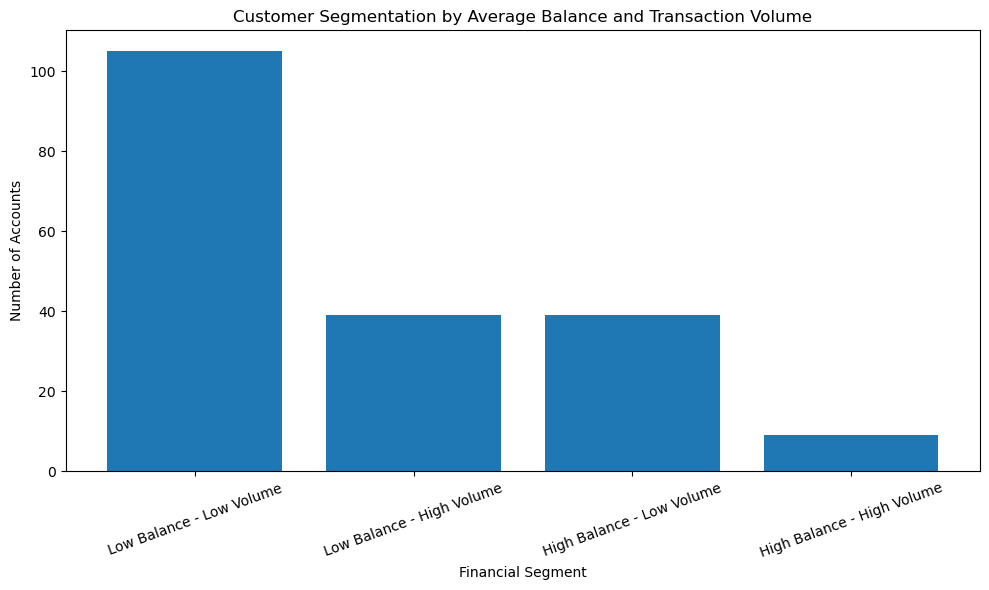

In [428]:
plt.figure(figsize=(10, 6))

plt.bar(
    financial_segment_summary["Financial_Segment"],
    financial_segment_summary["Account_Count"]
)

plt.title(
    "Customer Segmentation by Average Balance and Transaction Volume"
)

plt.xlabel("Financial Segment")
plt.ylabel("Number of Accounts")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Task 3.2 – Customer Segmentation by Average Balance and Transaction Volume (Rubric-Based Analysis)

### Segmentation Rubric

Customer accounts were segmented using the 75th percentile (Q3) as the threshold for identifying relatively high average balance and transaction volume.

- **High Balance:** Average Balance ≥ 85,165.73
- **Low Balance:** Average Balance < 85,165.73
- **High Volume:** Total Transaction Volume ≥ 295,923.08
- **Low Volume:** Total Transaction Volume < 295,923.08

Based on these thresholds, accounts were classified into four financial segments:

1. High Balance – High Volume
2. High Balance – Low Volume
3. Low Balance – High Volume
4. Low Balance – Low Volume

The thresholds were derived from the 75th percentile of the observed dataset rather than being arbitrarily selected.

### Key Insights

- The largest segment consists of 105 accounts (54.69%) classified as Low Balance – Low Volume. This indicates that more than half of the accounts have relatively lower balances and transaction activity.
- 39 accounts (20.31%) fall into the Low Balance – High Volume segment. These accounts show frequent or high-value transaction activity despite maintaining relatively lower average balances. They may require closer monitoring for liquidity pressure, balance depletion, or potential overdraft risk.
- Another 39 accounts (20.31%) are classified as High Balance – Low Volume. These accounts maintain relatively strong balances but have lower transaction volumes, which may indicate savings-oriented behavior or limited account usage.
- Only 9 accounts (4.69%) belong to the High Balance – High Volume segment. These accounts combine strong financial balances with high transaction activity and may represent valuable and highly engaged customers.
- Overall, the analysis shows that the customer base is dominated by lower-balance accounts, while only a small proportion combines both high financial capacity and high transaction activity.

# Task 3.3 – High-Net Inflow Account Profiles

In [429]:
df["Credit_Amount"] = df["TransactionAmount"].where(
    df["TransactionType"] == "Deposit",
    0
)

df["Debit_Amount"] = df["TransactionAmount"].where(
    df["TransactionType"].isin(["Withdrawal", "Payment"]),
    0
)

df[[
    "TransactionType",
    "TransactionAmount",
    "Credit_Amount",
    "Debit_Amount"
]].head(10)

,TransactionType,TransactionAmount,Credit_Amount,Debit_Amount
0,Withdrawal,47387.11457,0.00000,47387.11457
1,Payment,55806.54015,0.00000,55806.54015
2,Withdrawal,51080.47837,0.00000,51080.47837
3,Deposit,70472.70472,70472.70472,0.00000
4,Deposit,29830.48767,29830.48767,0.00000
5,Withdrawal,70066.06961,0.00000,70066.06961
6,Transfer,42066.63658,0.00000,0.00000
7,Transfer,66872.64962,0.00000,0.00000
8,Transfer,12765.97689,0.00000,0.00000
9,Transfer,63450.48439,0.00000,0.00000


In [430]:
account_summary = (
    df.groupby("AccountID")
    .agg(
        Total_Credit=("Credit_Amount", "sum"),
        Total_Debit=("Debit_Amount", "sum")
    )
    .reset_index()
)

account_summary["Net_Inflow"] = (
    account_summary["Total_Credit"]
    - account_summary["Total_Debit"]
)

account_summary.head(10)

,AccountID,Total_Credit,Total_Debit,Net_Inflow
0,ACC10117,56402.839110,107654.532150,-51251.693040
1,ACC10996,60870.237210,297946.784800,-237076.547590
2,ACC11062,0.000000,96820.851390,-96820.851390
3,ACC11188,138883.978382,145348.385422,-6464.407040
4,ACC11285,71079.928350,168577.238237,-97497.309887
5,ACC11837,0.000000,280003.838417,-280003.838417
6,ACC12182,130450.262350,49923.063810,80527.198540
7,ACC12334,0.000000,0.000000,0.000000
8,ACC13357,0.000000,157472.008730,-157472.008730
9,ACC15228,46141.121310,0.000000,46141.121310


In [431]:
account_summary["Net_Inflow"].describe()

count       192.000000
mean     -60953.689843
std      114224.378935
min     -395419.947830
25%     -131496.172710
50%      -54384.915545
75%        1203.591942
max      284230.600790
Name: Net_Inflow, dtype: float64

In [432]:
high_net_inflow_threshold = 1203.591942

account_summary["High_Net_Inflow_Flag"] = (
    account_summary["Net_Inflow"] >= high_net_inflow_threshold
)

account_summary.head(10)

,AccountID,Total_Credit,Total_Debit,Net_Inflow,High_Net_Inflow_Flag
0,ACC10117,56402.839110,107654.532150,-51251.693040,False
1,ACC10996,60870.237210,297946.784800,-237076.547590,False
2,ACC11062,0.000000,96820.851390,-96820.851390,False
3,ACC11188,138883.978382,145348.385422,-6464.407040,False
4,ACC11285,71079.928350,168577.238237,-97497.309887,False
5,ACC11837,0.000000,280003.838417,-280003.838417,False
6,ACC12182,130450.262350,49923.063810,80527.198540,True
7,ACC12334,0.000000,0.000000,0.000000,False
8,ACC13357,0.000000,157472.008730,-157472.008730,False
9,ACC15228,46141.121310,0.000000,46141.121310,True


In [433]:
high_net_inflow_summary = (
    account_summary["High_Net_Inflow_Flag"]
    .value_counts()
    .reset_index()
)

high_net_inflow_summary.columns = [
    "High_Net_Inflow_Flag",
    "Account_Count"
]

high_net_inflow_summary["Percentage"] = (
    high_net_inflow_summary["Account_Count"]
    / high_net_inflow_summary["Account_Count"].sum()
) * 100

high_net_inflow_summary

,High_Net_Inflow_Flag,Account_Count,Percentage
0,False,144,75.0
1,True,48,25.0


In [434]:
high_net_inflow_accounts = account_summary[
    account_summary["High_Net_Inflow_Flag"] == True
].copy()

high_net_inflow_accounts = high_net_inflow_accounts.sort_values(
    "Net_Inflow",
    ascending=False
)

high_net_inflow_accounts.head(10)

,AccountID,Total_Credit,Total_Debit,Net_Inflow,High_Net_Inflow_Flag
170,ACC88286,284230.600790,0.00000,284230.600790,True
24,ACC21719,281795.517800,7066.33208,274729.185720,True
102,ACC51200,251699.760080,50230.02764,201469.732440,True
43,ACC28295,262087.212310,62636.51939,199450.692920,True
169,ACC88252,183519.248820,0.00000,183519.248820,True
163,ACC83269,180850.726890,0.00000,180850.726890,True
171,ACC88449,184286.917040,50072.93893,134213.978110,True
58,ACC32627,141764.346710,15770.63227,125993.714440,True
56,ACC31902,103237.587600,0.00000,103237.587600,True
85,ACC45907,99707.422688,0.00000,99707.422688,True


In [435]:
high_net_inflow_profile = high_net_inflow_accounts.merge(
    customer_profile[
        [
            "AccountID",
            "Average_Balance",
            "Total_Transaction_Volume",
            "Transaction_Frequency",
            "Activity_Level",
            "Financial_Segment"
        ]
    ],
    on="AccountID",
    how="left"
)

high_net_inflow_profile.head(10)

,AccountID,Total_Credit,Total_Debit,Net_Inflow,High_Net_Inflow_Flag,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level,Financial_Segment
0,ACC88286,284230.600790,0.00000,284230.600790,True,71284.188672,284230.600790,5,Medium,Low Balance - Low Volume
1,ACC21719,281795.517800,7066.33208,274729.185720,True,72818.112908,288861.849880,4,Medium,Low Balance - Low Volume
2,ACC51200,251699.760080,50230.02764,201469.732440,True,72388.011257,301929.787720,4,Medium,Low Balance - High Volume
3,ACC28295,262087.212310,62636.51939,199450.692920,True,125043.309138,324723.731700,4,Medium,High Balance - High Volume
4,ACC88252,183519.248820,0.00000,183519.248820,True,86094.900381,187412.273607,5,Medium,High Balance - Low Volume
5,ACC83269,180850.726890,0.00000,180850.726890,True,93528.522860,180850.726890,2,Low,High Balance - Low Volume
6,ACC88449,184286.917040,50072.93893,134213.978110,True,65416.355338,206442.944320,5,Medium,Low Balance - Low Volume
7,ACC32627,141764.346710,15770.63227,125993.714440,True,93374.434050,186928.477310,4,Medium,High Balance - Low Volume
8,ACC31902,103237.587600,0.00000,103237.587600,True,65027.572310,122102.014220,2,Low,Low Balance - Low Volume
9,ACC45907,99707.422688,0.00000,99707.422688,True,62879.604810,157336.797351,4,Medium,Low Balance - Low Volume


In [436]:
high_net_inflow_accounts.shape

(48, 5)

In [437]:
high_net_inflow_accounts["Net_Inflow"].describe()

count        48.000000
mean      78261.777674
std       64443.812365
min        2421.155330
25%       41673.568210
50%       66799.901845
75%       92819.983485
max      284230.600790
Name: Net_Inflow, dtype: float64

In [438]:
high_net_inflow_profile[
    [
        "Average_Balance",
        "Total_Transaction_Volume",
        "Transaction_Frequency",
        "Net_Inflow"
    ]
].describe()

,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Net_Inflow
count,48.000000,48.000000,48.000000,48.000000
mean,78671.394030,200083.821508,3.770833,78261.777674
std,22635.744551,108297.156685,1.765383,64443.812365
min,23319.336055,30328.633618,1.000000,2421.155330
25%,66565.865138,119797.186935,2.000000,41673.568210
50%,72873.215599,187170.375458,4.000000,66799.901845
75%,90167.659371,285388.413063,5.000000,92819.983485
max,144593.276200,484644.209170,9.000000,284230.600790


## Task 3.3 – High-Net Inflow Account Profiles (Rubric-Based Analysis)

### High-Net Inflow Identification Rubric

High-net inflow accounts were identified using the 75th percentile (Q3) of the account-level Net Inflow distribution as the threshold.

- **High-Net Inflow Threshold:** Net Inflow ≥ ₹1,203.59
- **Total Accounts:** 192
- **High-Net Inflow Accounts:** 48
- **Percentage of Accounts:** 25%

The threshold was selected using a data-driven percentile-based approach. Accounts at or above the 75th percentile were classified as high-net inflow accounts.

### High-Net Inflow Account Profile

| Metric | Mean | Median |
|---|---:|---:|
| Average Balance | ₹78,671.39 | ₹72,873.22 |
| Total Transaction Volume | ₹200,083.82 | ₹187,170.38 |
| Transaction Frequency | 3.77 | 4.00 |
| Net Inflow | ₹78,261.78 | ₹66,799.90 |

### Key Insights

- 48 out of 192 accounts (25%) were classified as high-net inflow accounts.
- The average net inflow among these accounts was approximately ₹78,261.78, while the median was ₹66,799.90.
- The average transaction frequency was 3.77 transactions per account, indicating that high positive net inflow does not necessarily require frequent transactions.
- The average balance of high-net inflow accounts was ₹78,671.39, which is only moderately higher than the overall account average of ₹74,990.71.
- Net inflow varied considerably, ranging from approximately ₹2,421.16 to ₹284,230.60, indicating substantial differences in the strength of positive cash inflows.
- The average transaction volume was approximately ₹200,083.82, while the maximum reached ₹484,644.21, showing that some high-net inflow accounts have considerably higher transaction activity.
- High-net inflow accounts may represent valuable customer relationships and could be considered for personalized financial products, investment services, or premium banking offerings.
- These accounts should still be monitored for unusual transaction patterns because a positive net inflow alone does not guarantee low financial risk.

# Task 3.4 – High-Frequency Low-Balance Accounts.

In [439]:
customer_profile[
    [
        "Average_Balance",
        "Transaction_Frequency"
    ]
].describe()

,Average_Balance,Transaction_Frequency
count,192.000000,192.000000
mean,74990.709390,4.166667
std,21351.526278,2.021697
min,23319.336055,1.000000
25%,63455.058162,3.000000
50%,72577.426682,4.000000
75%,85165.727267,5.000000
max,171767.657800,13.000000


In [440]:
high_freq_low_balance = customer_profile[
    (customer_profile["Average_Balance"] < 63455.058162) &
    (customer_profile["Transaction_Frequency"] >= 5)
].copy()

high_freq_low_balance.head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level,Financial_Segment
2,ACC11062,57108.763888,328776.968270,6,High,Low Balance - High Volume
31,ACC24070,53811.388618,338136.693810,5,Medium,Low Balance - High Volume
62,ACC34431,55556.756888,464671.957070,8,High,Low Balance - High Volume
66,ACC35419,53390.330235,431811.670100,6,High,Low Balance - High Volume
77,ACC41829,61628.656517,765315.963850,13,High,Low Balance - High Volume
79,ACC42710,63115.146550,193930.962760,5,Medium,Low Balance - Low Volume
82,ACC43771,59242.759106,231026.573660,8,High,Low Balance - Low Volume
84,ACC45521,49875.368013,268616.530550,7,High,Low Balance - Low Volume
92,ACC48501,53845.585612,246853.193030,5,Medium,Low Balance - Low Volume
119,ACC61827,47266.088053,397844.231169,6,High,Low Balance - High Volume


In [441]:
high_freq_low_balance.shape

(15, 6)

In [442]:
high_freq_low_balance_count = len(high_freq_low_balance)

total_accounts = len(customer_profile)

high_freq_low_balance_percentage = (
    high_freq_low_balance_count / total_accounts
) * 100

print("High-Frequency Low-Balance Accounts:", high_freq_low_balance_count)
print("Percentage of Total Accounts:", 
      round(high_freq_low_balance_percentage, 2), "%")

High-Frequency Low-Balance Accounts: 15
Percentage of Total Accounts: 7.81 %


In [443]:
high_freq_low_balance[
    [
        "Average_Balance",
        "Total_Transaction_Volume",
        "Transaction_Frequency"
    ]
].describe()

,Average_Balance,Total_Transaction_Volume,Transaction_Frequency
count,15.000000,15.000000,15.000000
mean,55698.758210,391290.607928,6.866667
std,4250.267600,141283.039462,1.995232
min,47266.088053,193930.962760,5.000000
25%,53600.859426,298696.749410,6.000000
50%,55556.756888,397844.231169,6.000000
75%,58175.761497,455579.911320,7.500000
max,63115.146550,765315.963850,13.000000


In [444]:
high_freq_low_balance_sorted = high_freq_low_balance.sort_values(
    ["Transaction_Frequency", "Average_Balance"],
    ascending=[False, True]
)

high_freq_low_balance_sorted.head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level,Financial_Segment
77,ACC41829,61628.656517,765315.963850,13,High,Low Balance - High Volume
185,ACC96277,53257.609105,513842.944636,8,High,Low Balance - High Volume
62,ACC34431,55556.756888,464671.957070,8,High,Low Balance - High Volume
82,ACC43771,59242.759106,231026.573660,8,High,Low Balance - Low Volume
84,ACC45521,49875.368013,268616.530550,7,High,Low Balance - Low Volume
145,ACC76597,56524.016080,455525.584130,7,High,Low Balance - High Volume
153,ACC78581,60382.951011,357789.158391,7,High,Low Balance - High Volume
119,ACC61827,47266.088053,397844.231169,6,High,Low Balance - High Volume
66,ACC35419,53390.330235,431811.670100,6,High,Low Balance - High Volume
149,ACC77638,54284.430696,455634.238510,6,High,Low Balance - High Volume


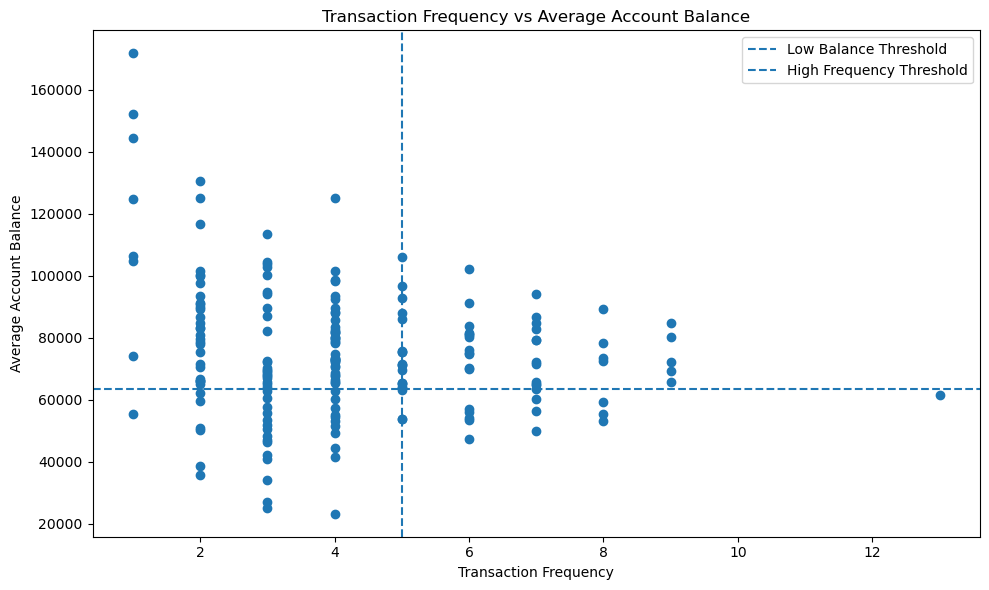

In [445]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_profile["Transaction_Frequency"],
    customer_profile["Average_Balance"]
)

plt.axhline(
    y=63455.058162,
    linestyle="--",
    label="Low Balance Threshold"
)

plt.axvline(
    x=5,
    linestyle="--",
    label="High Frequency Threshold"
)

plt.title(
    "Transaction Frequency vs Average Account Balance"
)

plt.xlabel("Transaction Frequency")
plt.ylabel("Average Account Balance")

plt.legend()

plt.tight_layout()
plt.show()

## Task 3.4 – High-Frequency Low-Balance Account Profiles (Rubric-Based Analysis)

### Identification Rubric

High-frequency low-balance accounts were identified using percentile-based thresholds derived from the account-level customer profile.

- **Low Balance:** Average Balance < ₹63,455.06 (25th percentile)
- **High Frequency:** Transaction Frequency ≥ 5 transactions (75th percentile)

An account was classified as a High-Frequency Low-Balance account only when both conditions were satisfied.

### Results

- **Total Accounts:** 192
- **High-Frequency Low-Balance Accounts:** 15
- **Percentage of Total Accounts:** 7.81%
- **Average Balance:** ₹55,698.76
- **Average Transaction Volume:** ₹391,290.61
- **Average Transaction Frequency:** 6.87 transactions

### Key Insights

- 15 accounts, representing 7.81% of the total 192 accounts, were identified as high-frequency low-balance accounts.
- These accounts have an average balance of approximately ₹55,698.76, which is below the dataset's 25th percentile threshold of ₹63,455.06.
- Despite maintaining relatively low balances, these accounts have an average transaction frequency of 6.87, indicating considerably higher activity than the overall account average of 4.17 transactions.
- The average transaction volume of these accounts is approximately ₹391,290.61, indicating that frequent activity can involve substantial transaction amounts.
- Transaction frequency ranges from 5 to 13 transactions, with ACC41829 recording the highest frequency of 13 transactions.
- ACC41829 is particularly noteworthy because it combines a relatively low average balance of approximately ₹61,628.66 with the highest transaction volume in this group at approximately ₹765,315.96.
- These accounts may face greater liquidity pressure because they maintain relatively lower balances while processing frequent transactions.
- Frequent withdrawals or payments could potentially increase the risk of rapid balance depletion or overdraft incidents.
- These accounts should be considered for enhanced monitoring, particularly when transaction frequency increases unexpectedly or when large withdrawals occur.
- Automated low-balance alerts, overdraft prevention notifications, and personalized financial planning support could help customers manage liquidity more effectively.

# Task 3.5 – Accounts with Negative or Near-Zero Balances.

In [446]:
customer_profile["Average_Balance"].describe()

count       192.000000
mean      74990.709390
std       21351.526278
min       23319.336055
25%       63455.058162
50%       72577.426682
75%       85165.727267
max      171767.657800
Name: Average_Balance, dtype: float64

In [447]:
near_zero_threshold = 30000

near_zero_accounts = customer_profile[
    customer_profile["Average_Balance"] <= near_zero_threshold
].copy()

near_zero_accounts

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level,Financial_Segment
11,ACC15671,27077.566847,134497.95972,3,Low,Low Balance - Low Volume
63,ACC34568,25206.101480,145216.83745,3,Low,Low Balance - Low Volume
64,ACC34821,23319.336055,222247.31977,4,Medium,Low Balance - Low Volume


In [448]:
near_zero_count = len(near_zero_accounts)

total_accounts = len(customer_profile)

near_zero_percentage = (
    near_zero_count / total_accounts
) * 100

print("Near-Zero Balance Accounts:", near_zero_count)
print(
    "Percentage of Total Accounts:",
    round(near_zero_percentage, 2),
    "%"
)

Near-Zero Balance Accounts: 3
Percentage of Total Accounts: 1.56 %


In [449]:
near_zero_accounts[
    [
        "Average_Balance",
        "Total_Transaction_Volume",
        "Transaction_Frequency",
        "Activity_Level",
        "Financial_Segment"
    ]
].describe()

,Average_Balance,Total_Transaction_Volume,Transaction_Frequency
count,3.000000,3.000000,3.000000
mean,25201.001461,167320.705647,3.333333
std,1879.120586,47868.813326,0.577350
min,23319.336055,134497.959720,3.000000
25%,24262.718768,139857.398585,3.000000
50%,25206.101480,145216.837450,3.000000
75%,26141.834163,183732.078610,3.500000
max,27077.566847,222247.319770,4.000000


In [450]:
near_zero_accounts.sort_values(
    "Average_Balance"
).head(10)

,AccountID,Average_Balance,Total_Transaction_Volume,Transaction_Frequency,Activity_Level,Financial_Segment
64,ACC34821,23319.336055,222247.31977,4,Medium,Low Balance - Low Volume
63,ACC34568,25206.101480,145216.83745,3,Low,Low Balance - Low Volume
11,ACC15671,27077.566847,134497.95972,3,Low,Low Balance - Low Volume


## Task 3.5 – Accounts with Negative or Near-Zero Balances (Rubric-Based Analysis)

### Identification Criteria

Accounts were analyzed based on their account-level Average Balance.

- **Negative Balance:** Average Balance < ₹0
- **Near-Zero Balance:** Average Balance ≤ ₹30,000

The ₹30,000 threshold was selected as a practical monitoring threshold because the dataset contains only positive average balances, with the minimum average balance being approximately ₹23,319.34.

### Results

- **Total Accounts:** 192
- **Accounts with Negative Average Balance:** 0
- **Near-Zero Balance Accounts:** 3
- **Percentage of Total Accounts:** 1.56%
- **Average Balance of Near-Zero Accounts:** ₹25,201.00
- **Average Transaction Volume:** ₹167,320.71
- **Average Transaction Frequency:** 3.33 transactions

### Key Insights

- No accounts in the dataset had a negative average balance.
- Only 3 out of 192 accounts (1.56%) were classified as near-zero balance accounts using the ₹30,000 threshold.
- The average balance of these three accounts was approximately ₹25,201, indicating that they maintain substantially lower balances than the overall account average of ₹74,990.71.
- The near-zero balance accounts had an average transaction frequency of 3.33 transactions, which is lower than the overall account average of 4.17 transactions.
- ACC34821 had the lowest average balance at approximately ₹23,319.34 and a transaction volume of approximately ₹222,247.32, making it the most important account in this group for liquidity monitoring.
- Although no negative average balances were observed, near-zero balance accounts may have limited financial buffers and could become vulnerable to balance depletion if large withdrawals or payments occur.
- These accounts should be monitored for sudden large debit transactions, declining balances, and changes in transaction frequency.
- Low-balance alerts and personalized financial guidance may help customers maintain sufficient liquidity and reduce potential overdraft risk.

# Task 4 – Financial Risk Identification

# Task 4.1 – Frequent Large Withdrawals or Overdrafts

In [451]:
withdrawals = df[
    df["TransactionType"] == "Withdrawal"
].copy()

withdrawals["TransactionAmount"].describe()

count       214.000000
mean      52864.049316
std       28528.109975
min      -20633.955780
25%       32979.336375
50%       53367.092680
75%       71825.436060
max      131774.388400
Name: TransactionAmount, dtype: float64

In [452]:
large_withdrawal_threshold = withdrawals[
    "TransactionAmount"
].quantile(0.75)

print(
    "Large Withdrawal Threshold:",
    round(large_withdrawal_threshold, 2)
)

Large Withdrawal Threshold: 71825.44


In [453]:
large_withdrawals = withdrawals[
    withdrawals["TransactionAmount"] >= large_withdrawal_threshold
].copy()

large_withdrawals.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,Month_Number,TransactionCategory,TransactionMonth,Credit_Amount,Debit_Amount
17,67,CUST5121,ACC70741,Credit,Withdrawal,Credit Card,Firm A,South,Manager 4,2023-10-16,...,0.709799,320,220,2023,October,10,Debit,2023-10,0.0,102114.78700
22,45,CUST5500,ACC78581,Current,Withdrawal,Mutual Fund,Firm A,North,Manager 4,2023-08-22,...,1.068751,389,77,2023,August,8,Debit,2023-08,0.0,97319.12594
36,120,CUST3109,ACC16241,Current,Withdrawal,Personal Loan,Firm B,South,Manager 1,2023-08-16,...,0.305677,444,54,2023,August,8,Debit,2023-08,0.0,76719.95995
69,84,CUST4684,ACC10996,Loan,Withdrawal,Credit Card,Firm D,South,Manager 3,2023-01-21,...,0.619748,504,47,2023,January,1,Debit,2023-01,0.0,104027.84520
79,115,CUST3810,ACC72197,Savings,Withdrawal,Savings Account,Firm D,East,Manager 4,2024-03-23,...,0.579985,578,89,2024,March,3,Debit,2024-03,0.0,112826.34400
82,115,CUST6526,ACC71938,Credit,Withdrawal,Personal Loan,Firm E,North,Manager 1,2024-01-12,...,0.350210,458,164,2024,January,1,Debit,2024-01,0.0,97611.73338
107,54,CUST2578,ACC78589,Credit,Withdrawal,Savings Account,Firm A,South,Manager 4,2023-09-06,...,0.405283,519,227,2023,September,9,Debit,2023-09,0.0,77094.30183
122,88,CUST6330,ACC30852,Current,Withdrawal,Home Loan,Firm B,East,Manager 2,2023-03-16,...,0.619150,636,6,2023,March,3,Debit,2023-03,0.0,91479.53628
123,116,CUST7730,ACC24070,Credit,Withdrawal,Personal Loan,Firm A,West,Manager 1,2023-04-09,...,0.334842,325,184,2023,April,4,Debit,2023-04,0.0,99268.01135
133,193,CUST9564,ACC19156,Loan,Withdrawal,Home Loan,Firm B,South,Manager 4,2024-06-11,...,0.360505,817,147,2024,June,6,Debit,2024-06,0.0,94881.99586


In [454]:
large_withdrawal_accounts = (
    large_withdrawals
    .groupby("AccountID")
    .agg(
        Large_Withdrawal_Count=("TransactionID", "count"),
        Total_Large_Withdrawal_Amount=("TransactionAmount", "sum"),
        Average_Large_Withdrawal=("TransactionAmount", "mean")
    )
    .reset_index()
    .sort_values(
        "Large_Withdrawal_Count",
        ascending=False
    )
)

large_withdrawal_accounts.head(10)

,AccountID,Large_Withdrawal_Count,Total_Large_Withdrawal_Amount,Average_Large_Withdrawal
45,ACC97411,2,253344.76290,126672.381450
40,ACC81631,2,167939.97516,83969.987580
33,ACC71938,2,199945.24588,99972.622940
36,ACC77592,2,169062.41824,84531.209120
37,ACC78581,2,194934.21593,97467.107965
7,ACC24070,2,182594.16403,91297.082015
1,ACC11285,2,162501.63413,81250.817065
42,ACC94907,2,177282.72531,88641.362655
41,ACC83005,1,106601.65210,106601.652100
31,ACC70741,1,102114.78700,102114.787000


In [455]:
large_withdrawal_accounts["Frequent_Large_Withdrawal_Flag"] = (
    large_withdrawal_accounts["Large_Withdrawal_Count"] >= 2
)

large_withdrawal_accounts.head(10)

,AccountID,Large_Withdrawal_Count,Total_Large_Withdrawal_Amount,Average_Large_Withdrawal,Frequent_Large_Withdrawal_Flag
45,ACC97411,2,253344.76290,126672.381450,True
40,ACC81631,2,167939.97516,83969.987580,True
33,ACC71938,2,199945.24588,99972.622940,True
36,ACC77592,2,169062.41824,84531.209120,True
37,ACC78581,2,194934.21593,97467.107965,True
7,ACC24070,2,182594.16403,91297.082015,True
1,ACC11285,2,162501.63413,81250.817065,True
42,ACC94907,2,177282.72531,88641.362655,True
41,ACC83005,1,106601.65210,106601.652100,False
31,ACC70741,1,102114.78700,102114.787000,False


In [456]:
frequent_large_withdrawal_count = (
    large_withdrawal_accounts[
        large_withdrawal_accounts[
            "Frequent_Large_Withdrawal_Flag"
        ] == True
    ].shape[0]
)

print(
    "Accounts with Frequent Large Withdrawals:",
    frequent_large_withdrawal_count
)

Accounts with Frequent Large Withdrawals: 8


In [457]:
withdrawals["TransactionAmount"].describe()

count       214.000000
mean      52864.049316
std       28528.109975
min      -20633.955780
25%       32979.336375
50%       53367.092680
75%       71825.436060
max      131774.388400
Name: TransactionAmount, dtype: float64

In [458]:
large_withdrawal_threshold = withdrawals[
    "TransactionAmount"
].quantile(0.75)

print(
    "Large Withdrawal Threshold:",
    round(large_withdrawal_threshold, 2)
)

Large Withdrawal Threshold: 71825.44


In [459]:
large_withdrawals = withdrawals[
    withdrawals["TransactionAmount"] >= large_withdrawal_threshold
].copy()

print("Number of Large Withdrawal Transactions:",
      len(large_withdrawals))

large_withdrawals.head(10)

Number of Large Withdrawal Transactions: 54


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,Month_Number,TransactionCategory,TransactionMonth,Credit_Amount,Debit_Amount
17,67,CUST5121,ACC70741,Credit,Withdrawal,Credit Card,Firm A,South,Manager 4,2023-10-16,...,0.709799,320,220,2023,October,10,Debit,2023-10,0.0,102114.78700
22,45,CUST5500,ACC78581,Current,Withdrawal,Mutual Fund,Firm A,North,Manager 4,2023-08-22,...,1.068751,389,77,2023,August,8,Debit,2023-08,0.0,97319.12594
36,120,CUST3109,ACC16241,Current,Withdrawal,Personal Loan,Firm B,South,Manager 1,2023-08-16,...,0.305677,444,54,2023,August,8,Debit,2023-08,0.0,76719.95995
69,84,CUST4684,ACC10996,Loan,Withdrawal,Credit Card,Firm D,South,Manager 3,2023-01-21,...,0.619748,504,47,2023,January,1,Debit,2023-01,0.0,104027.84520
79,115,CUST3810,ACC72197,Savings,Withdrawal,Savings Account,Firm D,East,Manager 4,2024-03-23,...,0.579985,578,89,2024,March,3,Debit,2024-03,0.0,112826.34400
82,115,CUST6526,ACC71938,Credit,Withdrawal,Personal Loan,Firm E,North,Manager 1,2024-01-12,...,0.350210,458,164,2024,January,1,Debit,2024-01,0.0,97611.73338
107,54,CUST2578,ACC78589,Credit,Withdrawal,Savings Account,Firm A,South,Manager 4,2023-09-06,...,0.405283,519,227,2023,September,9,Debit,2023-09,0.0,77094.30183
122,88,CUST6330,ACC30852,Current,Withdrawal,Home Loan,Firm B,East,Manager 2,2023-03-16,...,0.619150,636,6,2023,March,3,Debit,2023-03,0.0,91479.53628
123,116,CUST7730,ACC24070,Credit,Withdrawal,Personal Loan,Firm A,West,Manager 1,2023-04-09,...,0.334842,325,184,2023,April,4,Debit,2023-04,0.0,99268.01135
133,193,CUST9564,ACC19156,Loan,Withdrawal,Home Loan,Firm B,South,Manager 4,2024-06-11,...,0.360505,817,147,2024,June,6,Debit,2024-06,0.0,94881.99586


In [460]:
large_withdrawal_accounts = (
    large_withdrawals
    .groupby("AccountID")
    .agg(
        Large_Withdrawal_Count=("TransactionID", "count"),
        Total_Large_Withdrawal_Amount=("TransactionAmount", "sum"),
        Average_Large_Withdrawal=("TransactionAmount", "mean")
    )
    .reset_index()
    .sort_values(
        "Large_Withdrawal_Count",
        ascending=False
    )
)

large_withdrawal_accounts.head(10)

,AccountID,Large_Withdrawal_Count,Total_Large_Withdrawal_Amount,Average_Large_Withdrawal
45,ACC97411,2,253344.76290,126672.381450
40,ACC81631,2,167939.97516,83969.987580
33,ACC71938,2,199945.24588,99972.622940
36,ACC77592,2,169062.41824,84531.209120
37,ACC78581,2,194934.21593,97467.107965
7,ACC24070,2,182594.16403,91297.082015
1,ACC11285,2,162501.63413,81250.817065
42,ACC94907,2,177282.72531,88641.362655
41,ACC83005,1,106601.65210,106601.652100
31,ACC70741,1,102114.78700,102114.787000


In [461]:
large_withdrawal_accounts["Frequent_Large_Withdrawal_Flag"] = (
    large_withdrawal_accounts["Large_Withdrawal_Count"] >= 2
)

large_withdrawal_accounts.head(10)

,AccountID,Large_Withdrawal_Count,Total_Large_Withdrawal_Amount,Average_Large_Withdrawal,Frequent_Large_Withdrawal_Flag
45,ACC97411,2,253344.76290,126672.381450,True
40,ACC81631,2,167939.97516,83969.987580,True
33,ACC71938,2,199945.24588,99972.622940,True
36,ACC77592,2,169062.41824,84531.209120,True
37,ACC78581,2,194934.21593,97467.107965,True
7,ACC24070,2,182594.16403,91297.082015,True
1,ACC11285,2,162501.63413,81250.817065,True
42,ACC94907,2,177282.72531,88641.362655,True
41,ACC83005,1,106601.65210,106601.652100,False
31,ACC70741,1,102114.78700,102114.787000,False


In [462]:
frequent_large_withdrawal_count = (
    large_withdrawal_accounts[
        large_withdrawal_accounts[
            "Frequent_Large_Withdrawal_Flag"
        ] == True
    ].shape[0]
)

print(
    "Accounts with Frequent Large Withdrawals:",
    frequent_large_withdrawal_count
)

Accounts with Frequent Large Withdrawals: 8


In [463]:
negative_balance_transactions = df[
    df["AccountBalance"] < 0
].copy()

print(
    "Transactions with Negative Balance:",
    len(negative_balance_transactions)
)

negative_balance_transactions.head(10)

Transactions with Negative Balance: 18


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,Month_Number,TransactionCategory,TransactionMonth,Credit_Amount,Debit_Amount
7,37,CUST6210,ACC11062,Savings,Transfer,Mutual Fund,Firm C,North,Manager 2,2023-02-14,...,0.354048,737,190,2023,February,2,Transfer,2023-02,0.00000,0.00000
107,54,CUST2578,ACC78589,Credit,Withdrawal,Savings Account,Firm A,South,Manager 4,2023-09-06,...,0.405283,519,227,2023,September,9,Debit,2023-09,0.00000,77094.30183
115,173,CUST6210,ACC74631,Savings,Deposit,Home Loan,Firm C,South,Manager 4,2023-01-08,...,0.705421,743,23,2023,January,1,Credit,2023-01,72738.26426,0.00000
137,41,CUST9248,ACC88252,Savings,Deposit,Mutual Fund,Firm A,South,Manager 1,2024-02-04,...,0.289785,592,153,2024,February,2,Credit,2024-02,22725.76123,0.00000
172,20,CUST9843,ACC88516,Savings,Payment,Home Loan,Firm C,North,Manager 3,2023-01-13,...,0.913844,469,182,2023,January,1,Debit,2023-01,0.00000,39126.35851
196,23,CUST4003,ACC97225,Credit,Deposit,Personal Loan,Firm B,West,Manager 2,2023-09-26,...,0.860293,668,68,2023,September,9,Credit,2023-09,74213.77540,0.00000
251,132,CUST4373,ACC87602,Credit,Transfer,Savings Account,Firm A,South,Manager 2,2024-01-12,...,0.362637,388,148,2024,January,1,Transfer,2024-01,0.00000,0.00000
258,68,CUST9731,ACC46953,Loan,Payment,Credit Card,Firm A,West,Manager 3,2023-10-24,...,0.105018,512,227,2023,October,10,Debit,2023-10,0.00000,44911.00374
389,97,CUST4769,ACC45101,Savings,Payment,Home Loan,Firm D,Central,Manager 2,2024-02-09,...,0.387427,399,203,2024,February,2,Debit,2024-02,0.00000,91817.49051
402,95,CUST5545,ACC30787,Loan,Deposit,Personal Loan,Firm D,South,Manager 2,2023-02-21,...,0.494266,493,117,2023,February,2,Credit,2023-02,74497.85013,0.00000


## Task 4.1 – Frequent Large Withdrawals (Rubric-Based Analysis)

### Risk Identification Criteria

Large withdrawals were identified using a percentile-based approach.

- **Total Withdrawal Transactions:** 214
- **Large Withdrawal Threshold:** ₹71,825.44 (75th percentile)
- **Large Withdrawal Transactions:** 54
- **Frequent Large Withdrawal Criterion:** 2 or more large withdrawal transactions per account
- **Accounts with Frequent Large Withdrawals:** 8

### Key Insights

- 54 out of 214 withdrawal transactions were classified as large withdrawals using the 75th percentile threshold of ₹71,825.44.
- 8 accounts recorded at least two large withdrawal transactions and were therefore flagged for frequent large withdrawal activity.
- ACC97411 recorded the highest total large withdrawal amount among the flagged accounts at approximately ₹253,344.76, with an average large withdrawal of ₹126,672.38.
- ACC71938 and ACC78581 also showed relatively high total large withdrawal amounts of approximately ₹199,945.25 and ₹194,934.22 respectively.
- Repeated large withdrawals may indicate higher liquidity requirements, significant financial commitments, or potentially unusual transaction behavior.
- These accounts should be reviewed alongside their account balances, risk scores, transaction frequency, and overdraft indicators before being classified as high-risk customers.
- Large withdrawals alone do not confirm suspicious activity. Additional risk indicators should be considered to avoid false positives.
- The flagged accounts could be prioritized for enhanced transaction monitoring and customer-level risk assessment.

In [464]:
negative_balance_accounts = (
    negative_balance_transactions
    .groupby("AccountID")
    .agg(
        Overdraft_Incidents=("TransactionID", "count"),
        Minimum_Balance=("AccountBalance", "min")
    )
    .reset_index()
    .sort_values(
        "Overdraft_Incidents",
        ascending=False
    )
)

negative_balance_accounts

,AccountID,Overdraft_Incidents,Minimum_Balance
11,ACC78589,2,-25971.512010
0,ACC11062,1,-9084.224009
9,ACC64022,1,-11356.975610
15,ACC94907,1,-7738.893700
14,ACC88516,1,-9208.204563
13,ACC88252,1,-7644.952475
12,ACC87602,1,-5518.347956
10,ACC74631,1,-8820.480676
8,ACC46953,1,-26968.230900
1,ACC15671,1,-8225.602340


## Task 4.1 – Overdraft Analysis

### Risk Identification Criteria

An overdraft incident was defined as any transaction where the Account Balance became negative.

### Results

- Accounts with Overdraft Incidents: **17**
- Highest Overdraft Frequency: **ACC78589 (2 incidents)**
- Largest Negative Balance: **−₹35,891.00 (ACC39529)**

### Key Insights

- A total of 17 accounts experienced at least one overdraft during the analysis period.
- ACC78589 recorded two overdraft incidents, making it the account with the highest overdraft frequency.
- ACC39529 recorded the largest overdraft with an account balance of approximately **−₹35,891.00**.
- ACC34821 also experienced a significant overdraft of approximately **−₹32,532.52**.
- Frequent overdrafts may indicate poor liquidity management or financial stress.
- These customers should be monitored closely and may benefit from low-balance alerts, overdraft protection services, or financial counseling.
- Combining overdraft history with withdrawal behavior and risk scores can improve customer risk assessment.

# Task 4.2 – Balance Volatility

In [465]:
balance_volatility = (
    df.groupby("AccountID")
    .agg(
        Average_Balance=("AccountBalance", "mean"),
        Balance_STD=("AccountBalance", "std")
    )
    .reset_index()
)

balance_volatility["Coefficient_of_Variation"] = (
    balance_volatility["Balance_STD"]
    / balance_volatility["Average_Balance"]
)

balance_volatility = balance_volatility.sort_values(
    "Coefficient_of_Variation",
    ascending=False
)

balance_volatility.head(10)

,AccountID,Average_Balance,Balance_STD,Coefficient_of_Variation
154,ACC78589,34272.665816,86423.147835,2.521635
89,ACC46953,35656.159735,88564.262571,2.483842
64,ACC34821,23319.336055,48974.249807,2.100156
73,ACC39529,62774.934093,91165.113157,1.452253
11,ACC15671,27077.566847,30995.763211,1.144703
168,ACC87602,41022.300481,46348.764739,1.129843
69,ACC38559,66090.737960,70149.365923,1.061410
45,ACC28612,42258.706897,44658.868241,1.056797
187,ACC97225,53496.777053,51171.428405,0.956533
146,ACC76699,46970.955587,44554.662869,0.948558


In [466]:
balance_volatility[
    [
        "Balance_STD",
        "Coefficient_of_Variation"
    ]
].describe()

,Balance_STD,Coefficient_of_Variation
count,184.000000,184.000000
mean,30746.744279,0.460685
std,16582.277290,0.348738
min,791.574703,0.010664
25%,18377.109212,0.255479
50%,29221.079624,0.388688
75%,40074.992913,0.567744
max,91165.113157,2.521635


# Task 4.2 – Balance Volatility Analysis

In [467]:
volatility_threshold = balance_volatility["Coefficient_of_Variation"].quantile(0.75)

balance_volatility["High_Volatility_Flag"] = (
    balance_volatility["Coefficient_of_Variation"] >= volatility_threshold
)

balance_volatility.head(10)

,AccountID,Average_Balance,Balance_STD,Coefficient_of_Variation,High_Volatility_Flag
154,ACC78589,34272.665816,86423.147835,2.521635,True
89,ACC46953,35656.159735,88564.262571,2.483842,True
64,ACC34821,23319.336055,48974.249807,2.100156,True
73,ACC39529,62774.934093,91165.113157,1.452253,True
11,ACC15671,27077.566847,30995.763211,1.144703,True
168,ACC87602,41022.300481,46348.764739,1.129843,True
69,ACC38559,66090.737960,70149.365923,1.061410,True
45,ACC28612,42258.706897,44658.868241,1.056797,True
187,ACC97225,53496.777053,51171.428405,0.956533,True
146,ACC76699,46970.955587,44554.662869,0.948558,True


In [468]:
high_volatility = balance_volatility[
    balance_volatility["High_Volatility_Flag"] == True
]

print("High Volatility Accounts:", len(high_volatility))
print("Total Accounts:", len(balance_volatility))
print("Percentage:", round(len(high_volatility)/len(balance_volatility)*100,2), "%")

High Volatility Accounts: 46
Total Accounts: 192
Percentage: 23.96 %


In [469]:
high_volatility.head(10)

,AccountID,Average_Balance,Balance_STD,Coefficient_of_Variation,High_Volatility_Flag
154,ACC78589,34272.665816,86423.147835,2.521635,True
89,ACC46953,35656.159735,88564.262571,2.483842,True
64,ACC34821,23319.336055,48974.249807,2.100156,True
73,ACC39529,62774.934093,91165.113157,1.452253,True
11,ACC15671,27077.566847,30995.763211,1.144703,True
168,ACC87602,41022.300481,46348.764739,1.129843,True
69,ACC38559,66090.737960,70149.365923,1.061410,True
45,ACC28612,42258.706897,44658.868241,1.056797,True
187,ACC97225,53496.777053,51171.428405,0.956533,True
146,ACC76699,46970.955587,44554.662869,0.948558,True


## Task 4.2 – Balance Volatility Analysis

### Risk Identification Criteria

Balance volatility was measured using:

- Standard Deviation (STD)
- Coefficient of Variation (CV = STD / Average Balance)

Accounts with a Coefficient of Variation greater than or equal to the 75th percentile (CV ≥ 0.5677) were classified as High Volatility accounts.

### Results

- Total Accounts: **192**
- High Volatility Accounts: **46**
- Percentage of High Volatility Accounts: **23.96%**

### Key Insights

- Balance volatility was evaluated using the coefficient of variation to measure fluctuations relative to the average account balance.
- A total of **46 accounts (23.96%)** were identified as high-volatility accounts.
- **ACC78589** recorded the highest balance volatility (CV = **2.52**), indicating extremely unstable account balances.
- **ACC46953 (CV = 2.48)** and **ACC34821 (CV = 2.10)** also exhibited significant balance fluctuations.
- High volatility suggests irregular cash flows, large deposits and withdrawals, or inconsistent financial activity.
- These accounts should be prioritized for enhanced monitoring because frequent balance fluctuations may increase financial and operational risk.

In [470]:
# Task 4.3 – Detect Anomalies Using IQR Method

In [471]:
Q1 = df["TransactionAmount"].quantile(0.25)
Q3 = df["TransactionAmount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", round(Q1,2))
print("Q3:", round(Q3,2))
print("IQR:", round(IQR,2))
print("Lower Limit:", round(lower_limit,2))
print("Upper Limit:", round(upper_limit,2))

Q1: 34600.68
Q3: 73485.55
IQR: 38884.87
Lower Limit: -23726.62
Upper Limit: 131812.85


In [472]:
anomalies = df[
    (df["TransactionAmount"] < lower_limit) |
    (df["TransactionAmount"] > upper_limit)
]

print("Total Anomalous Transactions:", len(anomalies))

anomalies.head(10)

Total Anomalous Transactions: 7


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,Month_Number,TransactionCategory,TransactionMonth,Credit_Amount,Debit_Amount
168,141,CUST2443,ACC21719,Current,Deposit,Home Loan,Firm E,North,Manager 2,2023-06-18,...,0.326918,595,15,2023,June,6,Credit,2023-06,155241.42760,0.0000
264,133,CUST4780,ACC18057,Savings,Payment,Personal Loan,Firm D,Central,Manager 2,2023-11-25,...,0.593189,548,220,2023,November,11,Debit,2023-11,0.00000,144421.8432
306,190,CUST6565,ACC41829,Loan,Payment,Home Loan,Firm B,Central,Manager 3,2024-03-12,...,0.323887,808,27,2024,March,3,Debit,2024-03,0.00000,144271.2717
377,189,CUST1042,ACC83848,Loan,Payment,Personal Loan,Firm B,West,Manager 1,2024-02-09,...,0.459324,753,73,2024,February,2,Debit,2024-02,0.00000,137999.1893
481,20,CUST7793,ACC88449,Current,Transfer,Credit Card,Firm D,North,Manager 4,2023-06-19,...,0.507783,379,222,2023,June,6,Transfer,2023-06,0.00000,0.0000
640,67,CUST1962,ACC94203,Savings,Deposit,Home Loan,Firm C,South,Manager 2,2024-06-07,...,0.446908,608,129,2024,June,6,Credit,2024-06,-27308.23578,0.0000
755,30,CUST1888,ACC45101,Credit,Payment,Savings Account,Firm A,Central,Manager 1,2023-04-19,...,0.373506,619,175,2023,April,4,Debit,2023-04,0.00000,165004.5369


In [473]:
anomaly_accounts = (
    anomalies.groupby("AccountID")
    .agg(
        Anomaly_Count=("TransactionID", "count"),
        Average_Transaction=("TransactionAmount", "mean"),
        Maximum_Transaction=("TransactionAmount", "max")
    )
    .reset_index()
    .sort_values(
        "Anomaly_Count",
        ascending=False
    )
)

anomaly_accounts.head(10)

,AccountID,Anomaly_Count,Average_Transaction,Maximum_Transaction
0,ACC18057,1,144421.84320,144421.84320
1,ACC21719,1,155241.42760,155241.42760
2,ACC41829,1,144271.27170,144271.27170
3,ACC45101,1,165004.53690,165004.53690
4,ACC83848,1,137999.18930,137999.18930
5,ACC88449,1,-27916.91165,-27916.91165
6,ACC94203,1,-27308.23578,-27308.23578


In [474]:
anomaly_accounts["Suspicious_Flag"] = (
    anomaly_accounts["Anomaly_Count"] >= 2
)

anomaly_accounts.head(10)

,AccountID,Anomaly_Count,Average_Transaction,Maximum_Transaction,Suspicious_Flag
0,ACC18057,1,144421.84320,144421.84320,False
1,ACC21719,1,155241.42760,155241.42760,False
2,ACC41829,1,144271.27170,144271.27170,False
3,ACC45101,1,165004.53690,165004.53690,False
4,ACC83848,1,137999.18930,137999.18930,False
5,ACC88449,1,-27916.91165,-27916.91165,False
6,ACC94203,1,-27308.23578,-27308.23578,False


In [475]:
suspicious_accounts = anomaly_accounts[
    anomaly_accounts["Suspicious_Flag"] == True
]

print("Suspicious Accounts:", len(suspicious_accounts))
print("Total Accounts with Anomalies:", len(anomaly_accounts))

Suspicious Accounts: 0
Total Accounts with Anomalies: 7


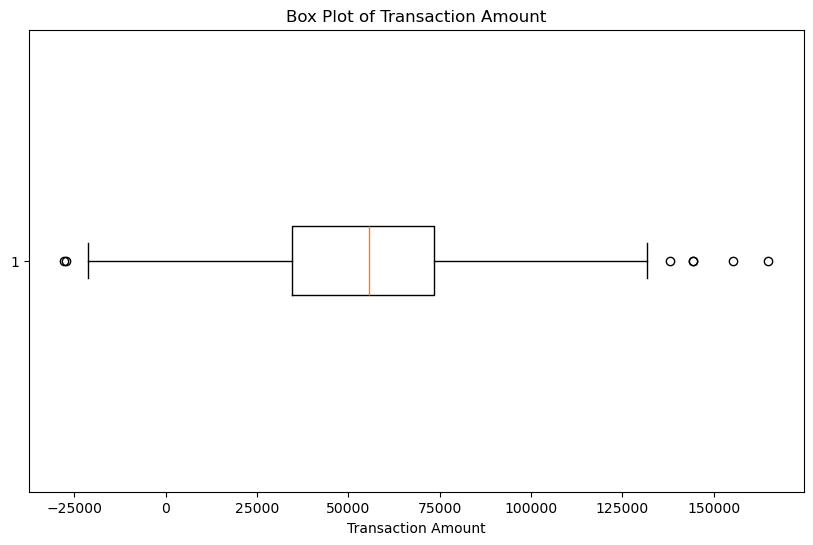

In [476]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(df["TransactionAmount"], vert=False)

plt.title("Box Plot of Transaction Amount")
plt.xlabel("Transaction Amount")

plt.show()

## Task 4.3 – Anomaly Detection Using IQR Method

### Risk Identification Criteria

The Interquartile Range (IQR) method was used to identify anomalous transactions.

- Q1 = ₹34,600.68
- Q3 = ₹73,485.55
- IQR = ₹38,884.87

Outlier Limits:

- Lower Limit = −₹23,726.62
- Upper Limit = ₹131,812.85

Transactions outside these limits were classified as anomalies.

### Results

- Total Anomalous Transactions: **7**
- Accounts with Anomalies: **7**
- Suspicious Accounts (2 or more anomalies): **0**

### Key Insights

- The IQR method identified seven transactions outside the expected transaction range.
- Five transactions exceeded the upper limit, representing unusually large financial transactions.
- Two transactions fell below the lower limit, indicating abnormal negative transaction values.
- Each anomalous transaction belonged to a different customer account.
- No account recorded multiple anomalous transactions; therefore, no account was classified as suspicious based on repeated anomalies.
- Although isolated anomalies are not necessarily fraudulent, they should be reviewed together with customer profiles and risk scores for a comprehensive financial risk assessment.

# Task 4.4 – Highlight Customers with Irregular or Suspicious Transaction Behavior

In [477]:
risk_summary = account_summary.merge(
    large_withdrawal_accounts[
        ["AccountID", "Frequent_Large_Withdrawal_Flag"]
    ],
    on="AccountID",
    how="left"
)

risk_summary = risk_summary.merge(
    balance_volatility[
        ["AccountID", "High_Volatility_Flag"]
    ],
    on="AccountID",
    how="left"
)

risk_summary = risk_summary.fillna(False)

In [478]:
overdraft_accounts = negative_balance_accounts.copy()

overdraft_accounts["Overdraft_Flag"] = True

risk_summary = risk_summary.merge(
    overdraft_accounts[
        ["AccountID", "Overdraft_Flag"]
    ],
    on="AccountID",
    how="left"
)

risk_summary["Overdraft_Flag"] = risk_summary[
    "Overdraft_Flag"
].fillna(False)

In [479]:
risk_summary["Risk_Flag_Count"] = (
    risk_summary["Frequent_Large_Withdrawal_Flag"].astype(int)
    + risk_summary["High_Volatility_Flag"].astype(int)
    + risk_summary["Overdraft_Flag"].astype(int)
)

In [480]:
high_risk_customers = risk_summary[
    risk_summary["Risk_Flag_Count"] >= 2
].sort_values(
    "Risk_Flag_Count",
    ascending=False
)

print("High Risk Customers:", len(high_risk_customers))

high_risk_customers.head(20)

High Risk Customers: 18


,AccountID,Total_Credit,Total_Debit,Net_Inflow,High_Net_Inflow_Flag,Frequent_Large_Withdrawal_Flag,High_Volatility_Flag,Overdraft_Flag,Risk_Flag_Count
182,ACC94907,40232.32905,251858.395810,-211626.066760,False,True,True,True,3
2,ACC11062,0.00000,96820.851390,-96820.851390,False,False,True,True,2
11,ACC15671,0.00000,54668.935450,-54668.935450,False,False,True,True,2
172,ACC88516,0.00000,130426.032320,-130426.032320,False,False,True,True,2
169,ACC88252,183519.24882,0.000000,183519.248820,True,False,True,True,2
168,ACC87602,0.00000,70152.771860,-70152.771860,False,False,True,True,2
154,ACC78589,0.00000,77094.301830,-77094.301830,False,False,True,True,2
148,ACC77592,0.00000,262254.424839,-262254.424839,False,True,True,False,2
141,ACC74631,98951.08638,28425.805630,70525.280750,True,False,True,True,2
123,ACC64022,0.00000,219205.793467,-219205.793467,False,False,True,True,2


## Task 4.4 – High-Risk Customer Identification

### Risk Identification Criteria

Customer risk was assessed using three financial risk indicators:

- Frequent Large Withdrawals
- High Balance Volatility
- Overdraft Incidents

Each account received one risk flag for every criterion satisfied.

Accounts with **two or more risk flags** were classified as **High-Risk Customers**.

### Results

- Total Accounts: **192**
- High-Risk Customers: **18**
- Percentage of High-Risk Customers: **9.38%**

### Key Insights

- A total of 18 customer accounts were identified as high risk based on multiple financial risk indicators.
- **ACC94907** was identified as the highest-risk account because it satisfied all three risk criteria: frequent large withdrawals, high balance volatility, and overdraft incidents.
- The remaining high-risk accounts satisfied two of the three risk indicators, suggesting persistent financial instability or irregular transaction behavior.
- Most high-risk customers exhibited high balance volatility together with overdraft incidents, indicating inconsistent cash flow management.
- These customers should be prioritized for enhanced transaction monitoring, personalized financial advisory services, and proactive fraud detection.
- Combining multiple risk indicators provides a more reliable customer risk assessment than evaluating any single metric independently.

# Task 5 – Visualization

#### Visualization 1: Monthly Credit vs Debit Trend (Line Chart)

In [481]:
monthly_pivot["TransactionMonth"] = monthly_pivot["TransactionMonth"].astype(str)

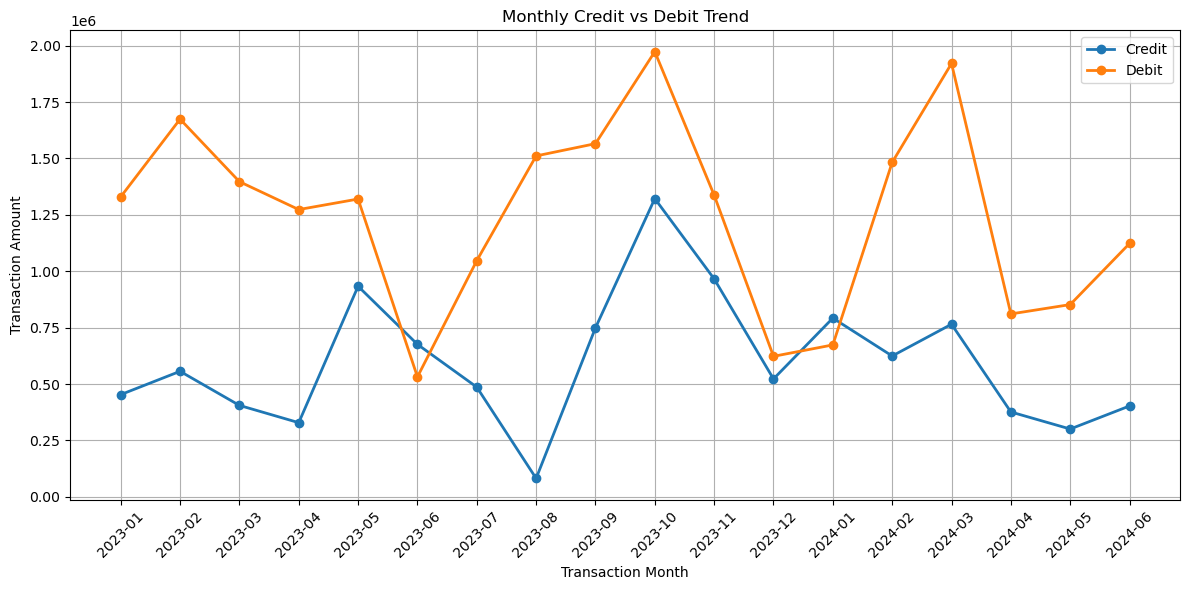

In [482]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(monthly_pivot["TransactionMonth"],
         monthly_pivot["Credit"],
         marker='o',
         linewidth=2,
         label="Credit")

plt.plot(monthly_pivot["TransactionMonth"],
         monthly_pivot["Debit"],
         marker='o',
         linewidth=2,
         label="Debit")

plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Visualization 1 – Monthly Credit vs Debit Trend

### Insights

- Debit transactions were higher than credit transactions during most months.
- June 2023 and January 2024 recorded positive net transaction values because credit exceeded debit.
- October 2023 had the highest transaction volume.
- August 2023 showed the largest negative net transaction.
- The overall trend indicates that customer outflows were generally higher than inflows.

## Visualization 2: Yearly Credit vs Debit Comparison (Grouped Bar Chart)

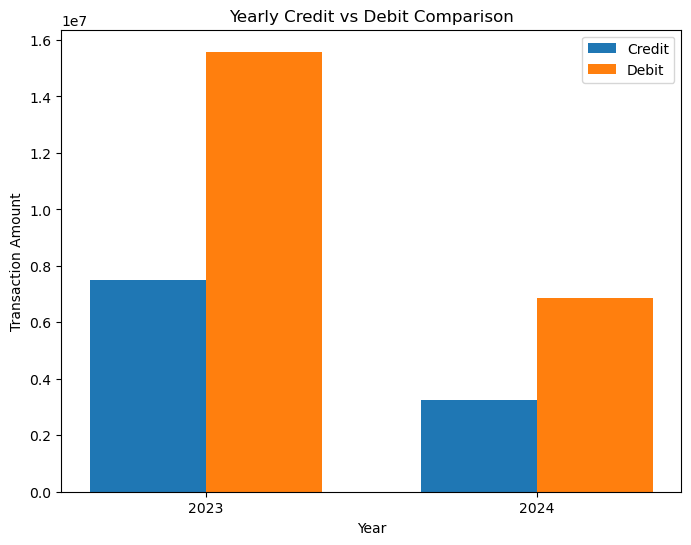

In [483]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(yearly_pivot))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2,
        yearly_pivot["Credit"],
        width,
        label="Credit")

plt.bar(x + width/2,
        yearly_pivot["Debit"],
        width,
        label="Debit")

plt.xticks(x, yearly_pivot["Year"])

plt.title("Yearly Credit vs Debit Comparison")
plt.xlabel("Year")
plt.ylabel("Transaction Amount")
plt.legend()

plt.show()

## Visualization 2 – Yearly Credit vs Debit Comparison

### Insights

- Debit transactions exceeded credit transactions in both 2023 and 2024.
- 2023 recorded the highest overall transaction volume.
- Customer spending remained consistently higher than deposits.
- The bank experienced an overall negative net transaction flow in both years.

### Visualization 3: Activity Level Distribution (Pie Chart)

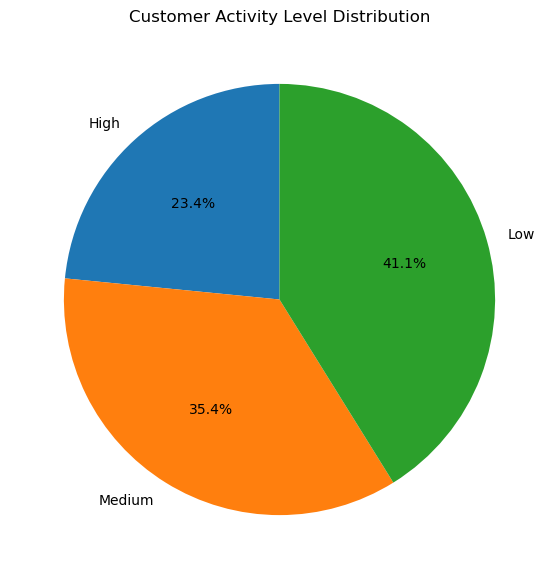

In [484]:
plt.figure(figsize=(7,7))

plt.pie(
    activity_summary["Account_Count"],
    labels=activity_summary["Activity_Level"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Activity Level Distribution")

plt.show()

## Visualization 3 – Customer Activity Level Distribution

### Insights

- Low activity accounts represent the largest customer group.
- Medium activity accounts form more than one-third of the customer base.
- High activity customers account for nearly one-quarter of all accounts.
- Increasing engagement among low activity customers may improve transaction volumes.

## Visualization 4 – Financial Segment Distribution

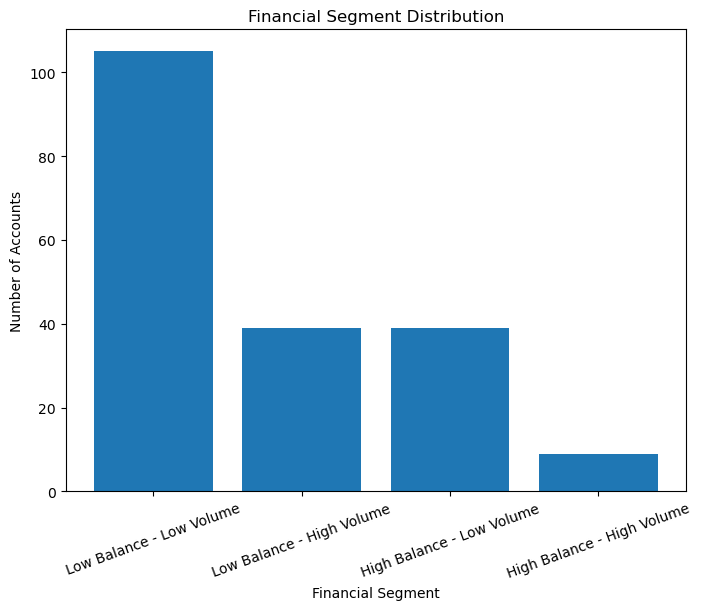

In [485]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.bar(
    financial_segment_summary["Financial_Segment"],
    financial_segment_summary["Account_Count"]
)

plt.title("Financial Segment Distribution")
plt.xlabel("Financial Segment")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=20)

plt.show()

## Visualization 4 – Financial Segment Distribution

### Insights

- More than half of the customers belong to the **Low Balance – Low Volume** segment.
- Only a small percentage of customers are classified as **High Balance – High Volume**.
- This indicates that most customers maintain moderate balances with relatively lower transaction activity.

## Visualization 5 – Top 10 High Net Inflow Accounts

In [486]:
top10 = top_accounts.reset_index().head(10)

In [487]:
print(top10.columns)

Index(['AccountID', 'Total_Credit', 'Total_Debit', 'Net_Inflow'], dtype='object')


In [488]:
top10 = top_accounts.head(10).reset_index()

print(top10.columns)

Index(['AccountID', 'Total_Credit', 'Total_Debit', 'Net_Inflow'], dtype='object')


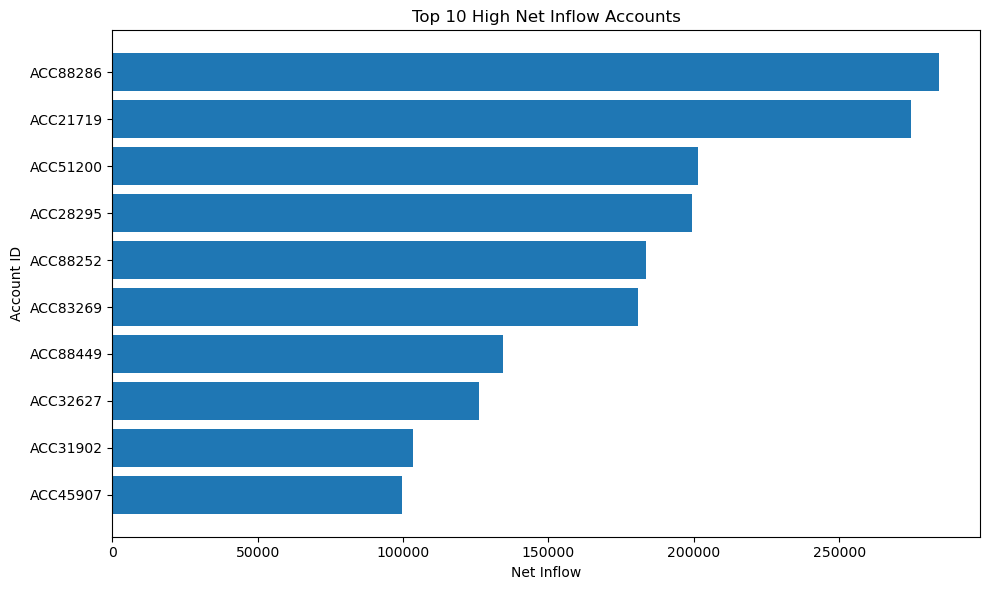

In [489]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10["AccountID"],
    top10["Net_Inflow"]
)

plt.title("Top 10 High Net Inflow Accounts")
plt.xlabel("Net Inflow")
plt.ylabel("Account ID")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Visualization 5 – Top 10 High Net Inflow Accounts

### Insights

- These accounts recorded the highest positive net inflows.
- They contribute significantly to the bank's incoming funds.
- Such customers may be valuable clients for premium banking services.

## Visualization 6 – High-Risk Customers

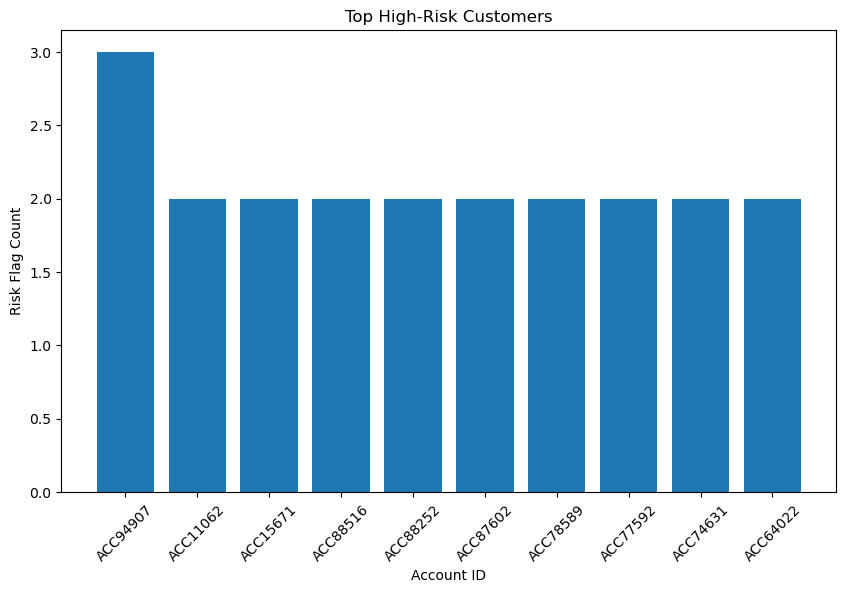

In [490]:
risk_plot = high_risk_customers.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    risk_plot["AccountID"],
    risk_plot["Risk_Flag_Count"]
)

plt.title("Top High-Risk Customers")
plt.xlabel("Account ID")
plt.ylabel("Risk Flag Count")

plt.xticks(rotation=45)

plt.show()

## Visualization 6 – High-Risk Customers

### Insights

- ACC94907 has the highest overall financial risk score.
- Other accounts have multiple financial risk indicators and require regular monitoring.
- Combining multiple risk indicators improves customer risk assessment.

## Visualization 7 – Transaction Amount Box Plot

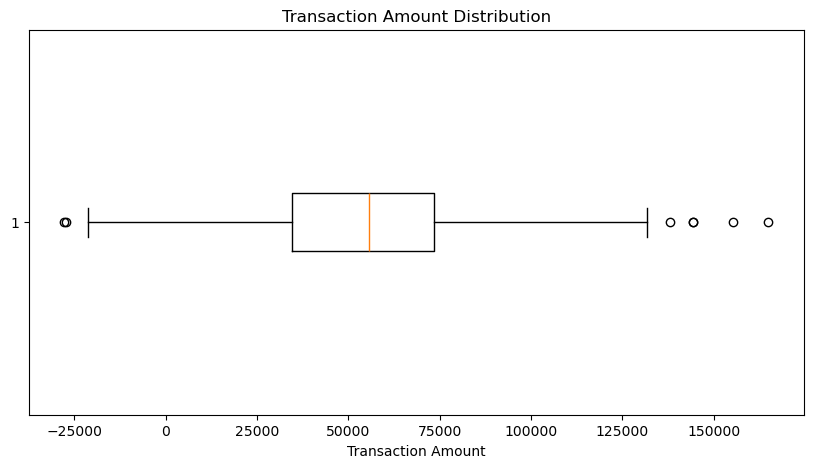

In [491]:
plt.figure(figsize=(10,5))

plt.boxplot(df["TransactionAmount"], vert=False)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")

plt.show()

## Visualization 7 – Transaction Amount Box Plot

### Insights

- Most transactions fall within a normal range.
- A few extreme values appear as outliers.
- These outliers were identified using the IQR method during the risk analysis.
- Monitoring these unusual transactions can help detect potential fraud or abnormal financial behavior.

# Task 6 – Statistical Analysis (Hypothesis Testing)

In [492]:
from scipy import stats

### Task 6.1 – Compare Average Transaction Amounts

In [493]:
deposit = df[df["TransactionType"] == "Deposit"]["TransactionAmount"]
withdrawal = df[df["TransactionType"] == "Withdrawal"]["TransactionAmount"]

t_stat, p_value = stats.ttest_ind(deposit, withdrawal, equal_var=False)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

T-statistic: 2.1382
P-value: 0.0331


## Task 6.1 – Hypothesis Test Results

### Results

- T-statistic: **2.1382**
- P-value: **0.0331**

### Decision

Since the p-value (0.0331) is less than the significance level (0.05), the null hypothesis is rejected.

### Interpretation

There is a statistically significant difference between the average transaction amounts of deposits and withdrawals.

### Business Insight

This indicates that customers tend to deposit and withdraw different amounts on average. Understanding this difference can help the bank improve cash flow forecasting, liquidity planning, and customer transaction analysis.

### Task 6.2 – Correlation Between Balance and Transaction Amount

In [494]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df["AccountBalance"],
    df["TransactionAmount"]
)

print("Correlation Coefficient:", round(corr, 4))
print("P-value:", round(p_value, 4))

Correlation Coefficient: -0.0752
P-value: 0.0335


## Task 6.2 – Correlation Analysis Results

### Results

- Correlation Coefficient (r): **-0.0752**
- P-value: **0.0335**

### Decision

Since the p-value (0.0335) is less than the significance level (0.05), the null hypothesis is rejected.

### Interpretation

There is a statistically significant relationship between account balance and transaction amount. However, the correlation coefficient (-0.0752) indicates that the relationship is **very weak and negative**.

### Business Insight

Although account balance has a statistically detectable relationship with transaction amount, the effect is very small. This suggests that transaction amounts are influenced more by other customer or account characteristics than by account balance alone.

## Video link:- https://www.loom.com/share/014f067de73e42f985248ff33e191afe